<a href="https://colab.research.google.com/github/trang1981/ELAPS/blob/main/Notebooks/VIB180cutoffngay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD DỮ LIỆU

XỬ LÝ FILE TARGET

In [ ]:
# ==========================================================
# CREATE TARGET FILE FOR 180-DAY LANDMARK EXPERIMENT
# ==========================================================

import os
import pandas as pd
import numpy as np
from google.colab import drive

# ==========================================================
# CONFIGURATION
# ==========================================================
LANDMARK_DAYS = 180

# ==========================================================
# MOUNT GOOGLE DRIVE
# ==========================================================
drive.mount("/content/drive", force_remount=True)

# ==========================================================
# PATHS
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "6.Data_Card.xlsx"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed180.csv"
)

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(
        f"Input file not found: {INPUT_FILE}"
    )

# ==========================================================
# READ DATA
# ==========================================================
card = pd.read_excel(INPUT_FILE)

card.columns = (
    card.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nColumns:")
print(card.columns.tolist())

# ==========================================================
# REQUIRED COLUMNS
# ==========================================================
required_columns = [
    "CUSTOMER_NUMBER",
    "COUNT_CREDITCARD",
    "MONTH"
]

missing_columns = [
    column
    for column in required_columns
    if column not in card.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

# ==========================================================
# SELECT AND CLEAN DATA
# ==========================================================
card = card[
    [
        "CUSTOMER_NUMBER",
        "COUNT_CREDITCARD",
        "MONTH"
    ]
].copy()

card = card.dropna(
    subset=["CUSTOMER_NUMBER"]
)

card["CUSTOMER_NUMBER"] = (
    card["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

card["COUNT_CREDITCARD"] = (
    pd.to_numeric(
        card["COUNT_CREDITCARD"],
        errors="coerce"
    )
    .fillna(0)
)

card["MONTH"] = pd.to_datetime(
    card["MONTH"],
    errors="coerce"
)

card = card.dropna(
    subset=["MONTH"]
)

# Nếu MONTH là dữ liệu theo tháng, chuẩn hóa về đầu tháng
card["MONTH"] = (
    card["MONTH"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Sắp xếp để kiểm soát dữ liệu dễ hơn
card = card.sort_values(
    by=["CUSTOMER_NUMBER", "MONTH"]
).reset_index(drop=True)

# ==========================================================
# REMOVE EXACT DUPLICATES IF ANY
# ==========================================================
before_duplicates = len(card)

card = card.drop_duplicates(
    subset=[
        "CUSTOMER_NUMBER",
        "MONTH",
        "COUNT_CREDITCARD"
    ]
)

print(
    "\nExact duplicate rows removed:",
    before_duplicates - len(card)
)

# ==========================================================
# CUSTOMER OBSERVATION SUMMARY
# ==========================================================
summary = (
    card
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        FIRST_OBS_MONTH=(
            "MONTH",
            "min"
        ),
        LAST_OBS_MONTH=(
            "MONTH",
            "max"
        ),
        TOTAL_CARD_ALL_PERIOD=(
            "COUNT_CREDITCARD",
            "sum"
        ),
        N_OBS_MONTHS=(
            "MONTH",
            "nunique"
        )
    )
)

# ==========================================================
# DEFINE 180-DAY LANDMARK WINDOW
# ==========================================================
summary["LANDMARK_DATE"] = summary["FIRST_OBS_MONTH"]

summary["CUTOFF_180D"] = (
    summary["LANDMARK_DATE"]
    + pd.Timedelta(days=LANDMARK_DAYS)
)

# ==========================================================
# FIRST CARD MONTH OVER THE FULL AVAILABLE PERIOD
# ==========================================================
first_card = (
    card.loc[
        card["COUNT_CREDITCARD"] > 0
    ]
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        FIRST_CARD_MONTH=(
            "MONTH",
            "min"
        )
    )
)

summary = summary.merge(
    first_card,
    on="CUSTOMER_NUMBER",
    how="left"
)

# ==========================================================
# CARD ADOPTION TIME
# ==========================================================
summary["DAYS_TO_FIRST_CARD"] = (
    summary["FIRST_CARD_MONTH"]
    - summary["LANDMARK_DATE"]
).dt.days

# ==========================================================
# CHECK SUFFICIENT FOLLOW-UP
# ==========================================================
# Khách hàng có:
# 1. phát sinh thẻ trong 180 ngày; hoặc
# 2. được quan sát đầy đủ ít nhất 180 ngày.
#
# Khách phát sinh thẻ trong cửa sổ vẫn hợp lệ dù dữ liệu sau đó
# không kéo dài đến ngày thứ 180 vì sự kiện đã được xác nhận.

summary["CARD_WITHIN_180D"] = (
    summary["FIRST_CARD_MONTH"].notna()
    & (
        summary["FIRST_CARD_MONTH"]
        >= summary["LANDMARK_DATE"]
    )
    & (
        summary["FIRST_CARD_MONTH"]
        <= summary["CUTOFF_180D"]
    )
)

summary["FULL_180D_FOLLOWUP"] = (
    summary["LAST_OBS_MONTH"]
    >= summary["CUTOFF_180D"]
)

summary["ELIGIBLE_180D"] = (
    summary["CARD_WITHIN_180D"]
    | summary["FULL_180D_FOLLOWUP"]
)

# ==========================================================
# KEEP ELIGIBLE CUSTOMERS
# ==========================================================
n_before_filter = len(summary)

summary_180d = summary.loc[
    summary["ELIGIBLE_180D"]
].copy()

n_excluded = (
    n_before_filter
    - len(summary_180d)
)

# ==========================================================
# CREATE 180-DAY TARGET
# ==========================================================
summary_180d["TARGET_180D"] = (
    summary_180d["CARD_WITHIN_180D"]
    .astype(int)
)

# Tên TARGET giúp tương thích với code huấn luyện cũ
summary_180d["TARGET"] = (
    summary_180d["TARGET_180D"]
)

# ==========================================================
# TARGET MONTH
# ==========================================================
# Positive:
#   thời điểm phát sinh thẻ đầu tiên.
#
# Negative:
#   ngày kết thúc cửa sổ dự báo 180 ngày.

summary_180d["TARGET_MONTH"] = (
    summary_180d["CUTOFF_180D"]
)

positive_mask = (
    summary_180d["TARGET_180D"] == 1
)

summary_180d.loc[
    positive_mask,
    "TARGET_MONTH"
] = summary_180d.loc[
    positive_mask,
    "FIRST_CARD_MONTH"
]

# ==========================================================
# OPTIONAL: NUMBER OF CARDS WITHIN 180 DAYS
# ==========================================================
card_with_landmark = card.merge(
    summary[
        [
            "CUSTOMER_NUMBER",
            "LANDMARK_DATE",
            "CUTOFF_180D"
        ]
    ],
    on="CUSTOMER_NUMBER",
    how="inner"
)

card_in_180d = card_with_landmark.loc[
    (
        card_with_landmark["MONTH"]
        >= card_with_landmark["LANDMARK_DATE"]
    )
    & (
        card_with_landmark["MONTH"]
        <= card_with_landmark["CUTOFF_180D"]
    )
].copy()

card_count_180d = (
    card_in_180d
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        TOTAL_CARD_180D=(
            "COUNT_CREDITCARD",
            "sum"
        )
    )
)

summary_180d = summary_180d.merge(
    card_count_180d,
    on="CUSTOMER_NUMBER",
    how="left"
)

summary_180d["TOTAL_CARD_180D"] = (
    summary_180d["TOTAL_CARD_180D"]
    .fillna(0)
)

# ==========================================================
# SELECT OUTPUT COLUMNS
# ==========================================================
output_columns = [
    "CUSTOMER_NUMBER",
    "LANDMARK_DATE",
    "CUTOFF_180D",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",
    "FIRST_CARD_MONTH",
    "DAYS_TO_FIRST_CARD",
    "N_OBS_MONTHS",
    "TOTAL_CARD_180D",
    "TOTAL_CARD_ALL_PERIOD",
    "FULL_180D_FOLLOWUP",
    "TARGET_MONTH",
    "TARGET_180D",
    "TARGET"
]

summary_180d = (
    summary_180d[output_columns]
    .sort_values("CUSTOMER_NUMBER")
    .reset_index(drop=True)
)

# ==========================================================
# VALIDATION CHECKS
# ==========================================================
invalid_positive = summary_180d.loc[
    (summary_180d["TARGET_180D"] == 1)
    & (
        (
            summary_180d["FIRST_CARD_MONTH"]
            < summary_180d["LANDMARK_DATE"]
        )
        | (
            summary_180d["FIRST_CARD_MONTH"]
            > summary_180d["CUTOFF_180D"]
        )
    )
]

if len(invalid_positive) > 0:
    raise ValueError(
        "Invalid positive cases detected outside the 180-day window."
    )

invalid_negative = summary_180d.loc[
    (summary_180d["TARGET_180D"] == 0)
    & (
        summary_180d["LAST_OBS_MONTH"]
        < summary_180d["CUTOFF_180D"]
    )
]

if len(invalid_negative) > 0:
    raise ValueError(
        "Negative cases without sufficient 180-day follow-up detected."
    )

# ==========================================================
# SAVE
# ==========================================================
summary_180d.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 60)
print("180-DAY LANDMARK TARGET RESULT")
print("=" * 60)

print("\nFirst rows:")
print(summary_180d.head())

print("\nOriginal customers :", n_before_filter)
print("Eligible customers :", len(summary_180d))
print("Excluded customers :", n_excluded)

print("\nTarget distribution:")
print(
    summary_180d["TARGET_180D"]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{summary_180d['TARGET_180D'].mean() * 100:.2f}%"
)

print("\nPositive adoption-time statistics:")
print(
    summary_180d.loc[
        summary_180d["TARGET_180D"] == 1,
        "DAYS_TO_FIRST_CARD"
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Mounted at /content/drive
Input : /content/drive/MyDrive/Fintect/6.Data_Card.xlsx
Output: /content/drive/MyDrive/Fintect/target_raw_processed180.csv

Columns:
['MONTH', 'COUNT_CREDITCARD', 'COUNT_DEBITCARD', 'CUSTOMER_NUMBER']

Exact duplicate rows removed: 0

180-DAY LANDMARK TARGET RESULT

First rows:
  CUSTOMER_NUMBER LANDMARK_DATE CUTOFF_180D FIRST_OBS_MONTH LAST_OBS_MONTH  \
0          100019    2019-06-01  2019-11-28      2019-06-01     2019-12-01   
1          100026    2019-04-01  2019-09-28      2019-04-01     2019-12-01   
2          100028    2019-01-01  2019-06-30      2019-01-01     2019-12-01   
3          100033    2019-05-01  2019-10-28      2019-05-01     2019-12-01   
4          100037    2019-06-01  2019-11-28      2019-06-01     2019-12-01   

  FIRST_CARD_MONTH  DAYS_TO_FIRST_CARD  N_OBS_MONTHS  TOTAL_CARD_180D  \
0       2019-06-01                 0.0             7                6   
1       2019-04-01                 0.0             9                6   
2      

4️⃣ Nối CUSTOMER với TARGET

In [ ]:
import os
import pandas as pd

# ==========================================================
# CONFIGURATION
# ==========================================================
LANDMARK_DAYS = 180

# ==========================================================
# PATH
# ==========================================================
BASE_DIR = "/content/drive/MyDrive/Fintect"

TARGET_RAW_FILE = os.path.join(
    BASE_DIR,
    "target_raw_processed180.csv"
)

CUSTOMER_FILE = os.path.join(
    BASE_DIR,
    "1.Data_Customer.csv"
)

OUTPUT_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_180d.csv"
)

print("Target raw file:", TARGET_RAW_FILE)
print("Customer file  :", CUSTOMER_FILE)
print("Output file    :", OUTPUT_FILE)

# ==========================================================
# CHECK FILES
# ==========================================================
for file_path in [
    TARGET_RAW_FILE,
    CUSTOMER_FILE
]:
    if not os.path.exists(file_path):
        raise FileNotFoundError(
            f"Không tìm thấy file: {file_path}"
        )

# ==========================================================
# READ DATA
# ==========================================================
target = pd.read_csv(
    TARGET_RAW_FILE,
    low_memory=False
)

customer = pd.read_csv(
    CUSTOMER_FILE,
    low_memory=False
)

# ==========================================================
# STANDARDIZE COLUMN NAMES
# ==========================================================
target.columns = (
    target.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

customer.columns = (
    customer.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nTarget columns:")
print(target.columns.tolist())

print("\nCustomer columns:")
print(customer.columns.tolist())

# ==========================================================
# CHECK REQUIRED COLUMNS
# ==========================================================
required_target_columns = [
    "CUSTOMER_NUMBER",
    "FIRST_CARD_MONTH",
    "LAST_OBS_MONTH"
]

missing_target = [
    col
    for col in required_target_columns
    if col not in target.columns
]

if missing_target:
    raise ValueError(
        f"Target thiếu cột: {missing_target}\n"
        f"Các cột hiện có: {target.columns.tolist()}"
    )

required_customer_columns = [
    "CUSTOMER_NUMBER",
    "CLIENT_CREATE_DATE"
]

missing_customer = [
    col
    for col in required_customer_columns
    if col not in customer.columns
]

if missing_customer:
    raise ValueError(
        f"Customer thiếu cột: {missing_customer}\n"
        f"Các cột hiện có: {customer.columns.tolist()}"
    )

# ==========================================================
# SELECT CUSTOMER COLUMNS
# ==========================================================
customer = customer[
    [
        "CUSTOMER_NUMBER",
        "CLIENT_CREATE_DATE"
    ]
].copy()

# ==========================================================
# CLEAN CUSTOMER NUMBER
# ==========================================================
customer = customer.dropna(
    subset=["CUSTOMER_NUMBER"]
)

target = target.dropna(
    subset=["CUSTOMER_NUMBER"]
)

customer["CUSTOMER_NUMBER"] = (
    customer["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

target["CUSTOMER_NUMBER"] = (
    target["CUSTOMER_NUMBER"]
    .astype(str)
    .str.strip()
)

# Loại CUSTOMER_NUMBER rỗng
customer = customer[
    customer["CUSTOMER_NUMBER"] != ""
].copy()

target = target[
    target["CUSTOMER_NUMBER"] != ""
].copy()

# ==========================================================
# CONVERT CUSTOMER DATE
# ==========================================================
customer["CLIENT_CREATE_DATE"] = pd.to_datetime(
    customer["CLIENT_CREATE_DATE"],
    errors="coerce"
)

customer = customer.dropna(
    subset=["CLIENT_CREATE_DATE"]
)

# Một khách hàng có thể xuất hiện nhiều dòng:
# lấy ngày bắt đầu quan hệ sớm nhất
customer = (
    customer
    .groupby(
        "CUSTOMER_NUMBER",
        as_index=False
    )
    .agg(
        RELATIONSHIP_START_DATE=(
            "CLIENT_CREATE_DATE",
            "min"
        )
    )
)

# ==========================================================
# CONVERT TARGET DATE COLUMNS
# ==========================================================
date_columns = [
    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",
    "TARGET_MONTH"
]

for col in date_columns:
    if col in target.columns:
        target[col] = pd.to_datetime(
            target[col],
            errors="coerce"
        )

# Bắt buộc phải có LAST_OBS_MONTH để kiểm tra follow-up
target = target.dropna(
    subset=["LAST_OBS_MONTH"]
)

# ==========================================================
# ENSURE ONE ROW PER CUSTOMER IN TARGET
# ==========================================================
duplicate_target = (
    target["CUSTOMER_NUMBER"]
    .duplicated()
    .sum()
)

if duplicate_target > 0:
    print(
        f"\nCảnh báo: target có {duplicate_target} "
        "CUSTOMER_NUMBER trùng."
    )

    # Gộp an toàn về một dòng mỗi khách
    aggregation = {
        "FIRST_CARD_MONTH": "min",
        "LAST_OBS_MONTH": "max"
    }

    if "FIRST_OBS_MONTH" in target.columns:
        aggregation["FIRST_OBS_MONTH"] = "min"

    if "TARGET_MONTH" in target.columns:
        aggregation["TARGET_MONTH"] = "min"

    target = (
        target
        .groupby(
            "CUSTOMER_NUMBER",
            as_index=False
        )
        .agg(aggregation)
    )

# ==========================================================
# MERGE TARGET AND CUSTOMER
# ==========================================================
n_target_before_merge = len(target)

landmark = target.merge(
    customer,
    on="CUSTOMER_NUMBER",
    how="inner",
    validate="one_to_one"
)

print("\nSố khách trước khi ghép:", n_target_before_merge)
print("Số khách sau khi ghép :", len(landmark))
print(
    "Số khách không ghép được:",
    n_target_before_merge - len(landmark)
)

# ==========================================================
# CREATE 180-DAY LANDMARK
# ==========================================================
landmark["LANDMARK_DATE"] = (
    landmark["RELATIONSHIP_START_DATE"]
    + pd.Timedelta(days=LANDMARK_DAYS)
)

# ==========================================================
# CHECK INVALID CARD DATES
# ==========================================================
# Trường hợp ngày mở thẻ trước ngày bắt đầu quan hệ là bất hợp lý
invalid_card_before_relationship = (
    landmark["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark["FIRST_CARD_MONTH"]
        < landmark["RELATIONSHIP_START_DATE"]
    )
)

n_invalid_card_dates = int(
    invalid_card_before_relationship.sum()
)

print(
    "\nKhách có ngày mở thẻ trước ngày bắt đầu quan hệ:",
    n_invalid_card_dates
)

# Loại các trường hợp sai thời gian
landmark = landmark[
    ~invalid_card_before_relationship
].copy()

# ==========================================================
# CHECK 180-DAY FOLLOW-UP
# ==========================================================
# Để xác định trạng thái tại landmark, khách hàng phải:
# - được quan sát đến ngày landmark; hoặc
# - đã mở thẻ trước landmark.
#
# Tuy nhiên, vì early adopter sẽ bị loại ở bước sau,
# tập eligible cuối cùng phải có LAST_OBS_MONTH >= LANDMARK_DATE.

landmark["HAS_180D_FOLLOWUP"] = (
    landmark["LAST_OBS_MONTH"]
    >= landmark["LANDMARK_DATE"]
)

n_without_followup = int(
    (~landmark["HAS_180D_FOLLOWUP"]).sum()
)

print(
    "Khách không đủ 180 ngày quan sát:",
    n_without_followup
)

landmark = landmark[
    landmark["HAS_180D_FOLLOWUP"]
].copy()

# ==========================================================
# IDENTIFY EARLY CARD ADOPTION
# ==========================================================
# Early adopter:
# mở thẻ từ ngày bắt đầu quan hệ đến hết ngày landmark 180 ngày.

landmark["EARLY_CARD_180D"] = (
    landmark["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark["FIRST_CARD_MONTH"]
        >= landmark["RELATIONSHIP_START_DATE"]
    )
    &
    (
        landmark["FIRST_CARD_MONTH"]
        <= landmark["LANDMARK_DATE"]
    )
)

n_early_adopters = int(
    landmark["EARLY_CARD_180D"].sum()
)

print(
    "Khách mở thẻ trong 180 ngày đầu:",
    n_early_adopters
)

# ==========================================================
# EXCLUDE EARLY ADOPTERS
# ==========================================================
# Tại landmark, chỉ giữ khách vẫn chưa có thẻ.
landmark_eligible = landmark[
    ~landmark["EARLY_CARD_180D"]
].copy()

print(
    "Số khách đủ điều kiện tại landmark 180 ngày:",
    len(landmark_eligible)
)

# ==========================================================
# CREATE NEW TARGET
# ==========================================================
# TARGET_180D = 1:
# khách mở thẻ sau landmark 180 ngày.
#
# TARGET_180D = 0:
# khách không mở thẻ trong toàn bộ thời gian quan sát.

landmark_eligible["TARGET_180D"] = (
    landmark_eligible["FIRST_CARD_MONTH"].notna()
    &
    (
        landmark_eligible["FIRST_CARD_MONTH"]
        > landmark_eligible["LANDMARK_DATE"]
    )
).astype(int)

# ==========================================================
# FEATURE CUTOFF
# ==========================================================
# Tất cả feature phải được xây dựng từ dữ liệu
# phát sinh không muộn hơn landmark 180 ngày.
landmark_eligible["FEATURE_CUTOFF_DATE"] = (
    landmark_eligible["LANDMARK_DATE"]
)

# ==========================================================
# DAYS FROM RELATIONSHIP START TO CARD
# ==========================================================
landmark_eligible["DAYS_TO_FIRST_CARD"] = (
    landmark_eligible["FIRST_CARD_MONTH"]
    - landmark_eligible["RELATIONSHIP_START_DATE"]
).dt.days

# ==========================================================
# DAYS FROM LANDMARK TO CARD
# ==========================================================
landmark_eligible["DAYS_AFTER_LANDMARK_TO_CARD"] = (
    landmark_eligible["FIRST_CARD_MONTH"]
    - landmark_eligible["LANDMARK_DATE"]
).dt.days

# ==========================================================
# SELECT OUTPUT COLUMNS
# ==========================================================
target_landmark_180d = landmark_eligible[
    [
        "CUSTOMER_NUMBER",
        "RELATIONSHIP_START_DATE",
        "LANDMARK_DATE",
        "FEATURE_CUTOFF_DATE",
        "FIRST_CARD_MONTH",
        "LAST_OBS_MONTH",
        "DAYS_TO_FIRST_CARD",
        "DAYS_AFTER_LANDMARK_TO_CARD",
        "TARGET_180D"
    ]
].copy()

# ==========================================================
# VALIDATION CHECKS
# ==========================================================

# Positive phải mở thẻ sau cutoff
invalid_positive = (
    (target_landmark_180d["TARGET_180D"] == 1)
    &
    (
        target_landmark_180d["FIRST_CARD_MONTH"].isna()
        |
        (
            target_landmark_180d["FIRST_CARD_MONTH"]
            <= target_landmark_180d["FEATURE_CUTOFF_DATE"]
        )
    )
).sum()

if invalid_positive > 0:
    raise ValueError(
        f"Có {invalid_positive} positive bị sai thời gian."
    )

# Negative không được có ngày mở thẻ sau cutoff.
# Nếu có FIRST_CARD_MONTH thì logic gán target đã sai.
invalid_negative = (
    (target_landmark_180d["TARGET_180D"] == 0)
    &
    target_landmark_180d["FIRST_CARD_MONTH"].notna()
).sum()

if invalid_negative > 0:
    raise ValueError(
        f"Có {invalid_negative} negative nhưng vẫn có ngày mở thẻ."
    )

# Tất cả khách phải đủ follow-up đến landmark
invalid_followup = (
    target_landmark_180d["LAST_OBS_MONTH"]
    < target_landmark_180d["LANDMARK_DATE"]
).sum()

if invalid_followup > 0:
    raise ValueError(
        f"Có {invalid_followup} khách không đủ 180 ngày follow-up."
    )

# Cutoff phải đúng 180 ngày sau relationship start
invalid_landmark = (
    (
        target_landmark_180d["LANDMARK_DATE"]
        - target_landmark_180d["RELATIONSHIP_START_DATE"]
    ).dt.days
    != LANDMARK_DAYS
).sum()

if invalid_landmark > 0:
    raise ValueError(
        f"Có {invalid_landmark} landmark không đúng "
        f"{LANDMARK_DAYS} ngày."
    )

# Feature cutoff phải bằng landmark
invalid_feature_cutoff = (
    target_landmark_180d["FEATURE_CUTOFF_DATE"]
    != target_landmark_180d["LANDMARK_DATE"]
).sum()

if invalid_feature_cutoff > 0:
    raise ValueError(
        f"Có {invalid_feature_cutoff} FEATURE_CUTOFF_DATE bị sai."
    )

# Mỗi khách chỉ xuất hiện một lần
duplicate_customers = (
    target_landmark_180d["CUSTOMER_NUMBER"]
    .duplicated()
    .sum()
)

if duplicate_customers > 0:
    raise ValueError(
        f"Có {duplicate_customers} CUSTOMER_NUMBER bị trùng."
    )

# Positive phải có số ngày sau landmark > 0
invalid_days_after_landmark = (
    (target_landmark_180d["TARGET_180D"] == 1)
    &
    (
        target_landmark_180d[
            "DAYS_AFTER_LANDMARK_TO_CARD"
        ] <= 0
    )
).sum()

if invalid_days_after_landmark > 0:
    raise ValueError(
        f"Có {invalid_days_after_landmark} positive "
        "không nằm sau landmark."
    )

# ==========================================================
# SORT AND SAVE
# ==========================================================
target_landmark_180d = (
    target_landmark_180d
    .sort_values("CUSTOMER_NUMBER")
    .reset_index(drop=True)
)

target_landmark_180d.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

# ==========================================================
# REPORT
# ==========================================================
print("\n" + "=" * 65)
print("LANDMARK 180-DAY TARGET")
print("=" * 65)

print("\nFirst rows:")
print(target_landmark_180d.head())

print("\nShape:", target_landmark_180d.shape)

print("\nPhân bố TARGET_180D:")
print(
    target_landmark_180d["TARGET_180D"]
    .value_counts()
    .sort_index()
)

positive_rate = (
    target_landmark_180d["TARGET_180D"].mean()
    * 100
)

print(
    "\nPositive rate:",
    round(positive_rate, 2),
    "%"
)

print(
    "\nSố positive:",
    int(
        target_landmark_180d["TARGET_180D"].sum()
    )
)

print(
    "Số negative:",
    int(
        (
            target_landmark_180d["TARGET_180D"] == 0
        ).sum()
    )
)

print("\nKhoảng cách landmark:")
print(
    (
        target_landmark_180d["LANDMARK_DATE"]
        - target_landmark_180d[
            "RELATIONSHIP_START_DATE"
        ]
    )
    .dt.days
    .value_counts()
    .sort_index()
)

print("\nThời gian mở thẻ sau landmark của positive:")
print(
    target_landmark_180d.loc[
        target_landmark_180d["TARGET_180D"] == 1,
        "DAYS_AFTER_LANDMARK_TO_CARD"
    ].describe()
)

print("\nKhoảng thời gian follow-up sau landmark:")
followup_after_landmark = (
    target_landmark_180d["LAST_OBS_MONTH"]
    - target_landmark_180d["LANDMARK_DATE"]
).dt.days

print(
    followup_after_landmark.describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Target raw file: /content/drive/MyDrive/Fintect/target_raw_processed180.csv
Customer file  : /content/drive/MyDrive/Fintect/1.Data_Customer.csv
Output file    : /content/drive/MyDrive/Fintect/target_landmark_180d.csv

Target columns:
['CUSTOMER_NUMBER', 'LANDMARK_DATE', 'CUTOFF_180D', 'FIRST_OBS_MONTH', 'LAST_OBS_MONTH', 'FIRST_CARD_MONTH', 'DAYS_TO_FIRST_CARD', 'N_OBS_MONTHS', 'TOTAL_CARD_180D', 'TOTAL_CARD_ALL_PERIOD', 'FULL_180D_FOLLOWUP', 'TARGET_MONTH', 'TARGET_180D', 'TARGET']

Customer columns:
['CUSTOMER_NUMBER', 'CLIENT_SEX', 'CLIENT_CREATE_DATE', 'DATE_OF_BIRTH', 'STAFF_VIB', 'IB_REGISTER_DATE', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD']

Số khách trước khi ghép: 85562
Số khách sau khi ghép : 85562
Số khách không ghép được: 0

Khách có ngày mở thẻ trước ngày bắt đầu quan hệ: 30097
Khách không đủ 180 ngày quan sát: 11571
Khách mở thẻ trong 180 ngày đầu: 4137
Số khách đủ điều kiện tại landmark 180 ngày: 39757

LANDMARK 180-DAY TARGET

First rows:
  CUSTOMER_NUMBER RELATIONS

6️⃣ Nối TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 180-DAY TRANSACTION FILTERING
#
# Mục tiêu:
# - Giữ toàn bộ khách hàng trong target_landmark_180d.csv
# - Chỉ giữ giao dịch từ ngày bắt đầu quan hệ
#   đến trước FEATURE_CUTOFF_DATE (ngày thứ 180)
# - Không làm mất khách hàng không có giao dịch hợp lệ
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

# File master Landmark 180 ngày
MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_180d.csv"
)

# File giao dịch gốc
TRANSACTION_FILE = os.path.join(
    BASE_DIR,
    "2.Data_MyVIB_Transaction.csv"
)

# Thư mục lưu kết quả
OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs"
)

# File giao dịch sau khi lọc 180 ngày
OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_180d.csv"
)

# File kiểm tra theo khách hàng
CUSTOMER_CHECK_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_180d_customer_check.csv"
)

# File thống kê
SUMMARY_FILE = os.path.join(
    OUTPUT_DIR,
    "step3_transaction_first_180d_summary.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN CONFIGURATION
# ============================================================

ID_COL = "CUSTOMER_NUMBER"

TARGET_COL = "TARGET_180D"

START_DATE_COL = "RELATIONSHIP_START_DATE"

CUTOFF_COL = "FEATURE_CUTOFF_DATE"

TRANS_DATE_COL = "TRANS_DATE"


# ============================================================
# 4. CHECK FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    TRANSACTION_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("MASTER_FILE:")
print(MASTER_FILE)

print("\nTRANSACTION_FILE:")
print(TRANSACTION_FILE)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)


# ============================================================
# 5. LOAD LANDMARK MASTER
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE MASTER DATA
# ============================================================

master = master.dropna(
    subset=[ID_COL]
).copy()

master[ID_COL] = (
    master[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master = master[
    master[ID_COL] != ""
].copy()

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

# Kiểm tra target chỉ chứa 0 và 1
invalid_target = master[
    ~master[TARGET_COL].isin([0, 1])
]

if not invalid_target.empty:
    raise ValueError(
        f"Có {len(invalid_target):,} khách hàng "
        f"có {TARGET_COL} không hợp lệ."
    )

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)


# ============================================================
# 7. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_customers = (
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_customers
)

if duplicate_customers > 0:

    duplicate_file = os.path.join(
        OUTPUT_DIR,
        "duplicate_master_customers.csv"
    )

    master.loc[
        master[ID_COL].duplicated(
            keep=False
        )
    ].to_csv(
        duplicate_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_180d.csv."
    )


# ============================================================
# 8. CHECK LANDMARK DATES
# ============================================================

invalid_dates = master[
    master[START_DATE_COL].isna()
    | master[CUTOFF_COL].isna()
    | (
        master[CUTOFF_COL]
        <= master[START_DATE_COL]
    )
]

print(
    "Customers with invalid dates:",
    len(invalid_dates)
)

if not invalid_dates.empty:

    invalid_dates_file = os.path.join(
        OUTPUT_DIR,
        "invalid_landmark_dates.csv"
    )

    invalid_dates.to_csv(
        invalid_dates_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Có khách hàng thiếu hoặc sai "
        "RELATIONSHIP_START_DATE / "
        "FEATURE_CUTOFF_DATE."
    )


# ============================================================
# 9. CHECK CUTOFF EXACTLY 180 DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark days distribution:")

print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
    .head(20)
)

invalid_180d = master[
    master["LANDMARK_DAYS_CHECK"]
    != LANDMARK_DAYS
]

if not invalid_180d.empty:

    invalid_180d_file = os.path.join(
        OUTPUT_DIR,
        "invalid_180d_landmark.csv"
    )

    invalid_180d.to_csv(
        invalid_180d_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_180d):,} khách hàng "
        f"không có landmark đúng {LANDMARK_DAYS} ngày."
    )


# ============================================================
# 10. LOAD TRANSACTION DATA
# ============================================================

trans = pd.read_csv(
    TRANSACTION_FILE,
    low_memory=False
)

trans.columns = (
    trans.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required_trans_cols = [
    ID_COL,
    TRANS_DATE_COL
]

missing_trans_cols = [
    col
    for col in required_trans_cols
    if col not in trans.columns
]

if missing_trans_cols:
    raise ValueError(
        f"File transaction thiếu cột: "
        f"{missing_trans_cols}\n"
        f"Các cột hiện có:\n"
        f"{trans.columns.tolist()}"
    )


# ============================================================
# 11. STANDARDIZE TRANSACTION DATA
# ============================================================

trans = trans.dropna(
    subset=[ID_COL]
).copy()

trans[ID_COL] = (
    trans[ID_COL]
    .astype(str)
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

trans = trans[
    trans[ID_COL] != ""
].copy()

trans[TRANS_DATE_COL] = pd.to_datetime(
    trans[TRANS_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("TRANSACTION DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(trans):,}"
)

print(
    "Customers:",
    f"{trans[ID_COL].nunique():,}"
)

print(
    "Missing TRANS_DATE:",
    f"{trans[TRANS_DATE_COL].isna().sum():,}"
)


# ============================================================
# 12. HANDLE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in trans.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột bị trùng giữa master "
        "và transaction:"
    )

    print(overlapping_cols)

    # Giữ các cột giao dịch từ trans,
    # loại các cột trùng khỏi master trước khi merge
    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 13. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master,
# kể cả khách hàng không có giao dịch.
# ============================================================

df = master_for_merge.merge(
    trans,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers after merge:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    df.loc[
        df[TARGET_COL] == 1,
        ID_COL
    ].nunique()
)

print(
    "Negative customers:",
    df.loc[
        df[TARGET_COL] == 0,
        ID_COL
    ].nunique()
)


# ============================================================
# 14. FILTER TRANSACTIONS IN FIRST 180 DAYS
#
# Giữ:
# 1. Khách không có giao dịch: TRANS_DATE là NaT
#
# 2. Giao dịch thỏa:
#    RELATIONSHIP_START_DATE <= TRANS_DATE
#    và
#    TRANS_DATE < FEATURE_CUTOFF_DATE
#
# Không dùng giao dịch:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau ngày thứ 180.
# ============================================================

valid_transaction_mask = (
    df[TRANS_DATE_COL].isna()
    |
    (
        df[TRANS_DATE_COL].notna()
        & df[START_DATE_COL].notna()
        & df[CUTOFF_COL].notna()
        & (
            df[TRANS_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[TRANS_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_transaction_mask
].copy()


# ============================================================
# 15. FIND CUSTOMERS LOST AFTER FILTERING
#
# Một khách có giao dịch, nhưng tất cả giao dịch:
# - trước ngày tạo khách hàng; hoặc
# - tại hoặc sau ngày thứ 180
#
# sẽ tạm biến mất sau khi lọc.
# Cần thêm lại khách với các trường giao dịch trống.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL].unique()
)

customers_after_raw_filter = set(
    df_filtered[ID_COL].unique()
)

lost_customers = (
    customers_before
    - customers_after_raw_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after raw filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 16. RESTORE LOST CUSTOMERS
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    transaction_only_cols = [
        col
        for col in trans.columns
        if col != ID_COL
    ]

    for col in transaction_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 17. FINAL CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 18. LEAKAGE CHECK
#
# Không được còn giao dịch:
# TRANS_DATE < RELATIONSHIP_START_DATE
# hoặc
# TRANS_DATE >= FEATURE_CUTOFF_DATE
# ============================================================

invalid_transaction_rows = df_filtered[
    df_filtered[TRANS_DATE_COL].notna()
    &
    (
        (
            df_filtered[TRANS_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[TRANS_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
]

print(
    "Invalid/leakage transaction rows:",
    len(invalid_transaction_rows)
)

if not invalid_transaction_rows.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "transaction_landmark_180d_leakage.csv"
    )

    invalid_transaction_rows.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn giao dịch ngoài cửa sổ "
        "180 ngày."
    )


# ============================================================
# 19. COUNT VALID TRANSACTIONS PER CUSTOMER
# ============================================================

transaction_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        TRANSACTION_COUNT_FIRST_180D=(
            TRANS_DATE_COL,
            "count"
        )
    )
)

transaction_count[
    "NO_TRANSACTION_FIRST_180D"
] = (
    transaction_count[
        "TRANSACTION_COUNT_FIRST_180D"
    ] == 0
).astype(int)


# ============================================================
# 20. CUSTOMER CHECK FILE
# ============================================================

customer_check = (
    master_for_merge[
        [
            ID_COL,
            TARGET_COL,
            START_DATE_COL,
            CUTOFF_COL
        ]
    ]
    .merge(
        transaction_count,
        on=ID_COL,
        how="left",
        validate="one_to_one"
    )
)

customer_check[
    "TRANSACTION_COUNT_FIRST_180D"
] = (
    customer_check[
        "TRANSACTION_COUNT_FIRST_180D"
    ]
    .fillna(0)
    .astype(int)
)

customer_check[
    "NO_TRANSACTION_FIRST_180D"
] = (
    customer_check[
        "NO_TRANSACTION_FIRST_180D"
    ]
    .fillna(1)
    .astype(int)
)


# ============================================================
# 21. SUMMARY BY TARGET
# ============================================================

summary = (
    df_filtered
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        CUSTOMERS=(
            ID_COL,
            "nunique"
        ),
        TRANSACTION_ROWS=(
            TRANS_DATE_COL,
            "count"
        ),
        EARLIEST_TRANSACTION=(
            TRANS_DATE_COL,
            "min"
        ),
        LATEST_TRANSACTION=(
            TRANS_DATE_COL,
            "max"
        )
    )
)

no_transaction_summary = (
    customer_check
    .groupby(
        TARGET_COL,
        as_index=False
    )
    .agg(
        CUSTOMERS_WITH_NO_TRANSACTION=(
            "NO_TRANSACTION_FIRST_180D",
            "sum"
        ),
        MEAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_180D",
            "mean"
        ),
        MEDIAN_TRANSACTION_COUNT=(
            "TRANSACTION_COUNT_FIRST_180D",
            "median"
        )
    )
)

summary = summary.merge(
    no_transaction_summary,
    on=TARGET_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 22. SORT OUTPUT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            TRANS_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 23. SAVE OUTPUTS
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)

customer_check.to_csv(
    CUSTOMER_CHECK_FILE,
    index=False,
    encoding="utf-8-sig"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 180-DAY TRANSACTION FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with no transaction in first 180 days:",
    f"{customer_check['NO_TRANSACTION_FIRST_180D'].sum():,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_transaction_rows):,}"
)

print("\nSummary:")
print(summary)

print("\nSaved transaction file:")
print(OUTPUT_FILE)

print("\nSaved customer check:")
print(CUSTOMER_CHECK_FILE)

print("\nSaved summary:")
print(SUMMARY_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
MASTER_FILE:
/content/drive/MyDrive/Fintect/target_landmark_180d.csv

TRANSACTION_FILE:
/content/drive/MyDrive/Fintect/2.Data_MyVIB_Transaction.csv

OUTPUT_DIR:
/content/drive/MyDrive/Fintect/landmark_180d_outputs

Duplicate customers in master: 0
Customers with invalid dates: 0

Landmark days distribution:
LANDMARK_DAYS_CHECK
180    39757
Name: count, dtype: int64

TRANSACTION DATA
Rows: 1,418,030
Customers: 52,488
Missing TRANS_DATE: 0

BEFORE FILTERING
Rows: 643,523
Customers after merge: 39,757
Expected customers: 39,757
Positive customers: 2674
Negative customers: 37083

AFTER RAW FILTERING
Rows: 362,924
Customers after raw filter: 38,202
Customers temporarily lost: 1,555
Customers after restoration: 39,757


/tmp/ipykernel_625/3155869033.py:609: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Invalid/leakage transaction rows: 0

LANDMARK 180-DAY TRANSACTION FILTER COMPLETED

Output rows: 364,479
Final customers: 39,757
Customers with no transaction in first 180 days: 27,546
Leakage rows: 0

Summary:
   TARGET_180D  CUSTOMERS  TRANSACTION_ROWS EARLIEST_TRANSACTION  \
0            0      37083            325005           2019-01-02   
1            1       2674             11928           2019-01-08   

  LATEST_TRANSACTION  CUSTOMERS_WITH_NO_TRANSACTION  MEAN_TRANSACTION_COUNT  \
0         2019-11-30                          25309                8.764259   
1         2019-11-28                           2237                4.460733   

   MEDIAN_TRANSACTION_COUNT  
0                       0.0  
1                       0.0  

Saved transaction file:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step3_transaction_first_180d.csv

Saved customer check:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step3_transaction_first_180d_customer_check.csv

Saved summary:
/cont

TẠO FEATURE CHO TRANSACTION

In [ ]:
# ============================================================
# LANDMARK 180-DAY TRANSACTION FEATURE EXTRACTION
#
# Không mã hóa TRANS_LV1_MODE và TRANS_LV2_MODE
# Chỉ lưu một file feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step3_transaction_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "transaction_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_transaction_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"

DATE_COL = "TRANS_DATE"
AMOUNT_COL = "TRANS_AMOUNT"
LV1_COL = "TRANS_LV1"
LV2_COL = "TRANS_LV2"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc giao dịch 180 ngày trước."
    )

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. HELPER FUNCTIONS
# ============================================================

def standardize_customer_id(
    series: pd.Series
) -> pd.Series:

    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def clean_category(
    series: pd.Series
) -> pd.Series:

    result = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    return result.replace({
        "": pd.NA,
        "NAN": pd.NA,
        "<NA>": pd.NA,
        "NONE": pd.NA,
        "NULL": pd.NA
    })


def get_mode_value(
    series: pd.Series
):

    valid = clean_category(
        series
    ).dropna()

    if valid.empty:
        return "NO_TRANSACTION"

    counts = valid.value_counts()
    max_count = counts.max()

    candidates = (
        counts[counts == max_count]
        .index
        .astype(str)
        .tolist()
    )

    # Nếu có nhiều mode cùng tần suất,
    # chọn theo thứ tự chữ cái để kết quả tái lập
    return sorted(candidates)[0]


# ============================================================
# 5. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 6. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    AMOUNT_COL,
    LV1_COL,
    LV2_COL
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE DATA
# ============================================================

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

# Làm sạch TRANS_AMOUNT
df[AMOUNT_COL] = (
    df[AMOUNT_COL]
    .astype("string")
    .str.replace(
        ",",
        "",
        regex=False
    )
    .str.strip()
)

df[AMOUNT_COL] = pd.to_numeric(
    df[AMOUNT_COL],
    errors="coerce"
)

df[LV1_COL] = clean_category(
    df[LV1_COL]
)

df[LV2_COL] = clean_category(
    df[LV2_COL]
)

# Loại dòng thiếu mã khách hoặc target
df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

# Loại CUSTOMER_NUMBER rỗng
df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK TARGET CONSISTENCY
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

inconsistent_target = target_check[
    target_check > 1
]

if not inconsistent_target.empty:

    print("\nKhách có target không nhất quán:")
    print(inconsistent_target.head())

    raise ValueError(
        f"Một khách hàng có nhiều giá trị {TARGET_COL}."
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đủ khách hàng, kể cả khách không có giao dịch.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID TRANSACTION ROWS
#
# Dòng TRANS_DATE trống chỉ dùng để giữ khách,
# không dùng để tính feature.
# ============================================================

valid_transactions = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid transaction rows:",
    f"{len(valid_transactions):,}"
)

print(
    "Customers with transaction:",
    f"{valid_transactions[ID_COL].nunique():,}"
)


# ============================================================
# 11. AGGREGATE FEATURES
# ============================================================

if not valid_transactions.empty:

    aggregated = (
        valid_transactions
        .groupby(ID_COL)
        .agg(
            TRANS_LV1_MODE=(
                LV1_COL,
                get_mode_value
            ),
            TRANS_LV2_MODE=(
                LV2_COL,
                get_mode_value
            ),
            TRANS_AMOUNT_MAX=(
                AMOUNT_COL,
                "max"
            ),
            TRANS_AMOUNT_MEAN=(
                AMOUNT_COL,
                "mean"
            ),
            TRANSACTION_COUNT_FIRST_180D=(
                DATE_COL,
                "count"
            )
        )
        .reset_index()
    )

else:

    aggregated = pd.DataFrame(
        columns=[
            ID_COL,
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN",
            "TRANSACTION_COUNT_FIRST_180D"
        ]
    )


# ============================================================
# 12. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    aggregated,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 13. FILL CUSTOMERS WITHOUT TRANSACTIONS
# ============================================================

feature_full["TRANS_LV1_MODE"] = (
    feature_full["TRANS_LV1_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full["TRANS_LV2_MODE"] = (
    feature_full["TRANS_LV2_MODE"]
    .fillna("NO_TRANSACTION")
)

feature_full[
    [
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
] = (
    feature_full[
        [
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .fillna(0)
)

feature_full[
    "TRANSACTION_COUNT_FIRST_180D"
] = (
    feature_full[
        "TRANSACTION_COUNT_FIRST_180D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 14. FINAL FEATURE TABLE
#
# Không lưu TARGET_180D vì target đã nằm trong bảng master.
# Không lưu TRANSACTION_COUNT để giữ đúng bộ feature cũ.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "TRANS_LV1_MODE",
        "TRANS_LV2_MODE",
        "TRANS_AMOUNT_MAX",
        "TRANS_AMOUNT_MEAN"
    ]
].copy()


# ============================================================
# 15. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_final[
        [
            "TRANS_LV1_MODE",
            "TRANS_LV2_MODE",
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_transaction = int(
    (
        feature_full[
            "TRANSACTION_COUNT_FIRST_180D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Customers without transaction:",
    f"{customers_without_transaction:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 16. ADDITIONAL SANITY CHECKS
# ============================================================

# Kiểm tra số giao dịch không âm
if (
    feature_full[
        "TRANSACTION_COUNT_FIRST_180D"
    ] < 0
).any():
    raise ValueError(
        "TRANSACTION_COUNT_FIRST_180D có giá trị âm."
    )

# Khách không có giao dịch phải có amount bằng 0
invalid_no_transaction_amount = (
    (
        feature_full[
            "TRANSACTION_COUNT_FIRST_180D"
        ] == 0
    )
    &
    (
        (
            feature_full["TRANS_AMOUNT_MAX"]
            != 0
        )
        |
        (
            feature_full["TRANS_AMOUNT_MEAN"]
            != 0
        )
    )
).sum()

if invalid_no_transaction_amount > 0:
    raise ValueError(
        f"Có {invalid_no_transaction_amount} khách "
        "không có giao dịch nhưng amount khác 0."
    )

# Khách không có giao dịch phải có mode NO_TRANSACTION
invalid_no_transaction_mode = (
    (
        feature_full[
            "TRANSACTION_COUNT_FIRST_180D"
        ] == 0
    )
    &
    (
        (
            feature_full["TRANS_LV1_MODE"]
            != "NO_TRANSACTION"
        )
        |
        (
            feature_full["TRANS_LV2_MODE"]
            != "NO_TRANSACTION"
        )
    )
).sum()

if invalid_no_transaction_mode > 0:
    raise ValueError(
        f"Có {invalid_no_transaction_mode} khách "
        "không có giao dịch nhưng mode không đúng."
    )


# ============================================================
# 17. SORT AND SAVE ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 18. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("TRANSACTION FEATURES 180-DAY COMPLETED")
print("=" * 70)

print("\nShape:", feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nFeature statistics:")
print(
    feature_final[
        [
            "TRANS_AMOUNT_MAX",
            "TRANS_AMOUNT_MEAN"
        ]
    ].describe()
)

print(
    "\nCustomers without transaction:",
    f"{customers_without_transaction:,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Input file:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step3_transaction_first_180d.csv

Output file:
/content/drive/MyDrive/Fintect/transaction_features_180d/feature_transaction_landmark_180d.csv

Input shape: (364479, 17)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'DAYS_TO_FIRST_CARD', 'DAYS_AFTER_LANDMARK_TO_CARD', 'TARGET_180D', 'LANDMARK_DAYS_CHECK', 'TRANS_LV1', 'TRANS_LV2', 'TRANS_DATE', 'DAY_OF_WEEK', 'TRANS_HOUR', 'TRANS_NO', 'TRANS_AMOUNT']

Expected customers: 39,757
Valid transaction rows: 336,933
Customers with transaction: 12,211

VALIDATION
Expected customers: 39,757
Final customers: 39,757
Duplicate customers: 0
Missing feature values: 0
Customers without transaction: 27,546

TRANSACTION FEATURES 180-DAY COMPLETED

Shape: (39757, 5)

First row

Activity → nối với TARGET

In [ ]:
# ============================================================
# LANDMARK 180-DAY ACTIVITY FILTERING
#
# Giữ activity trong 180 ngày đầu:
# RELATIONSHIP_START_DATE <= ACTIVITY_DATE < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có activity.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_180d.csv"
)

ACTIVITY_FILE = os.path.join(
    BASE_DIR,
    "3.Data_MyVIB_Activity.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step4_activity_first_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

ACTIVITY_DATE_COL = "ACTIVITY_DATE"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    ACTIVITY_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nActivity:")
print(ACTIVITY_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK 180D
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master = master.dropna(
    subset=[ID_COL]
).copy()

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master = master[
    master[ID_COL].notna()
    & (master[ID_COL].str.len() > 0)
].copy()

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_180d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK WINDOW
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")

print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"]
    != LANDMARK_DAYS
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_activity_landmark_180d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        f"không có landmark đúng {LANDMARK_DAYS} ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD ACTIVITY DATA
# ============================================================

activity = pd.read_csv(
    ACTIVITY_FILE,
    low_memory=False
)

activity.columns = (
    activity.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK ACTIVITY COLUMNS
# ============================================================

required_activity_cols = [
    ID_COL,
    ACTIVITY_DATE_COL
]

missing_activity_cols = [
    col
    for col in required_activity_cols
    if col not in activity.columns
]

if missing_activity_cols:
    raise ValueError(
        f"File activity thiếu các cột: "
        f"{missing_activity_cols}\n"
        f"Các cột hiện có:\n"
        f"{activity.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE ACTIVITY
# ============================================================

activity = activity.dropna(
    subset=[ID_COL]
).copy()

activity[ID_COL] = (
    activity[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

activity = activity[
    activity[ID_COL].notna()
    & (activity[ID_COL].str.len() > 0)
].copy()

activity[ACTIVITY_DATE_COL] = pd.to_datetime(
    activity[ACTIVITY_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW ACTIVITY DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(activity):,}"
)

print(
    "Customers:",
    f"{activity[ID_COL].nunique():,}"
)

print(
    "Missing ACTIVITY_DATE:",
    f"{activity[ACTIVITY_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in activity.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nOverlapping columns removed from master:"
    )
    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    activity,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER ACTIVITY IN FIRST 180 DAYS
#
# Giữ:
# - khách không có activity;
# - activity từ ngày bắt đầu quan hệ;
# - activity trước ngày cutoff 180.
#
# Không giữ:
# - activity trước ngày bắt đầu quan hệ;
# - activity tại hoặc sau ngày 180.
# ============================================================

valid_activity_mask = (
    df[ACTIVITY_DATE_COL].isna()
    |
    (
        df[ACTIVITY_DATE_COL].notna()
        & (
            df[ACTIVITY_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[ACTIVITY_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_activity_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
#
# Khách có activity nhưng toàn bộ activity nằm ngoài
# cửa sổ 180 ngày sẽ bị mất sau bước lọc.
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Thêm lại một dòng khách hàng với các cột activity để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    activity_only_cols = [
        col
        for col in activity.columns
        if col != ID_COL
    ]

    for col in activity_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn activity:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau feature cutoff.
# ============================================================

invalid_activity = df_filtered[
    df_filtered[ACTIVITY_DATE_COL].notna()
    &
    (
        (
            df_filtered[ACTIVITY_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[ACTIVITY_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage activity rows:",
    f"{len(invalid_activity):,}"
)

if not invalid_activity.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "activity_landmark_180d_leakage.csv"
    )

    invalid_activity.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn activity ngoài cửa sổ "
        "180 ngày."
    )


# ============================================================
# 20. ACTIVITY COUNT PER CUSTOMER
# ============================================================

activity_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        ACTIVITY_COUNT_FIRST_180D=(
            ACTIVITY_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD ACTIVITY COUNT
# ============================================================

df_filtered = df_filtered.merge(
    activity_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "ACTIVITY_COUNT_FIRST_180D"
] = (
    df_filtered[
        "ACTIVITY_COUNT_FIRST_180D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            ACTIVITY_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_without_activity = int(
    (
        activity_count[
            "ACTIVITY_COUNT_FIRST_180D"
        ] == 0
    ).sum()
)

customers_with_activity = int(
    (
        activity_count[
            "ACTIVITY_COUNT_FIRST_180D"
        ] > 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 180-DAY ACTIVITY FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with activity:",
    f"{customers_with_activity:,}"
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_activity):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_180d.csv

Activity:
/content/drive/MyDrive/Fintect/3.Data_MyVIB_Activity.csv

Output:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step4_activity_first_180d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
180    39757
Name: count, dtype: int64

RAW ACTIVITY DATA
Rows: 16,132,675
Customers: 77,741
Missing ACTIVITY_DATE: 0

BEFORE FILTERING
Rows: 5,703,358
Customers: 39,757
Expected customers: 39,757
Positive customers: 2,674
Negative customers: 37,083

AFTER RAW FILTERING
Rows: 3,238,917
Customers after filter: 38,077
Customers temporarily lost: 1,680


/tmp/ipykernel_625/1319414221.py:541: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Customers after restoration: 39,757
Invalid/leakage activity rows: 0

LANDMARK 180-DAY ACTIVITY FILTER COMPLETED

Output rows: 3,240,597
Final customers: 39,757
Customers with activity: 14,985
Customers without activity: 24,772
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step4_activity_first_180d.csv


TẠO FEATURE CHO ACTIVITY

In [ ]:
# ============================================================
# LANDMARK 180-DAY ACTIVITY FEATURE EXTRACTION
#
# Input:
#   landmark_180d_outputs/step4_activity_first_180d.csv
#
# Features:
#   LOGIN_PER_ACTIVE_DAY
#   INTEREST_RATE_RATIO
#
# Chỉ lưu một file feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step4_activity_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "activity_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_activity_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"

DATE_COL = "ACTIVITY_DATE"
ACTIVITY_COL = "ACTIVITY_NAME"


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n\n"
        "Hãy chạy bước lọc activity trong 180 ngày trước."
    )

print("=" * 70)
print("LANDMARK 180-DAY ACTIVITY FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    TARGET_COL,
    DATE_COL,
    ACTIVITY_COL
]

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"File đầu vào thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()


# ============================================================
# 7. STANDARDIZE TARGET
# ============================================================

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(int)
)

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. STANDARDIZE DATE AND ACTIVITY NAME
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)

df[ACTIVITY_COL] = (
    df[ACTIVITY_COL]
    .astype("string")
    .str.strip()
    .str.upper()
)

df[ACTIVITY_COL] = df[ACTIVITY_COL].replace({
    "": pd.NA,
    "NAN": pd.NA,
    "<NA>": pd.NA,
    "NONE": pd.NA,
    "NULL": pd.NA
})


# ============================================================
# 9. CHECK TARGET CONSISTENCY
#
# Một khách hàng chỉ được có một TARGET_180D.
# ============================================================

target_check = (
    df
    .groupby(ID_COL)[TARGET_COL]
    .nunique()
)

inconsistent_customers = int(
    (target_check > 1).sum()
)

print(
    "\nCustomers with inconsistent TARGET_180D:",
    inconsistent_customers
)

if inconsistent_customers > 0:
    raise ValueError(
        "Một số khách hàng có nhiều giá trị TARGET_180D."
    )


# ============================================================
# 10. CREATE CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có activity.
# ============================================================

customer_base = (
    df[
        [
            ID_COL,
            TARGET_COL
        ]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 11. SELECT VALID ACTIVITY ROWS
#
# ACTIVITY_DATE trống chỉ dùng để giữ khách hàng,
# không dùng để tính feature.
# ============================================================

valid = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid activity rows:",
    f"{len(valid):,}"
)

print(
    "Customers with activity:",
    f"{valid[ID_COL].nunique():,}"
)


# ============================================================
# 12. CREATE ACTIVITY FLAGS
# ============================================================

valid["IS_LOGIN"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "LOGIN",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["IS_INTEREST"] = (
    valid[ACTIVITY_COL]
    .str.contains(
        "INTEREST_RATE",
        case=False,
        na=False,
        regex=False
    )
    .astype(int)
)

valid["HAS_ACTIVITY"] = 1


# ============================================================
# 13. FEATURE ENGINEERING
# ============================================================

if not valid.empty:

    feat = (
        valid
        .groupby(ID_COL)
        .agg(
            LOGIN_COUNT=(
                "IS_LOGIN",
                "sum"
            ),
            INTEREST_COUNT=(
                "IS_INTEREST",
                "sum"
            ),
            TOTAL_ACTIVITY=(
                "HAS_ACTIVITY",
                "sum"
            ),
            ACTIVE_DAYS=(
                DATE_COL,
                lambda x: (
                    x.dt.normalize()
                    .nunique()
                )
            )
        )
        .reset_index()
    )

else:

    feat = pd.DataFrame(
        columns=[
            ID_COL,
            "LOGIN_COUNT",
            "INTEREST_COUNT",
            "TOTAL_ACTIVITY",
            "ACTIVE_DAYS"
        ]
    )


# ============================================================
# 14. CALCULATE FINAL FEATURES
# ============================================================

feat["LOGIN_PER_ACTIVE_DAY"] = (
    feat["LOGIN_COUNT"]
    /
    feat["ACTIVE_DAYS"].replace(
        0,
        np.nan
    )
).fillna(0)

feat["INTEREST_RATE_RATIO"] = (
    feat["INTEREST_COUNT"]
    /
    feat["TOTAL_ACTIVITY"].replace(
        0,
        np.nan
    )
).fillna(0)


# ============================================================
# 15. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_full = customer_base.merge(
    feat,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT ACTIVITY
# ============================================================

count_cols = [
    "LOGIN_COUNT",
    "INTEREST_COUNT",
    "TOTAL_ACTIVITY",
    "ACTIVE_DAYS"
]

feature_cols = [
    "LOGIN_PER_ACTIVE_DAY",
    "INTEREST_RATE_RATIO"
]

feature_full[
    count_cols + feature_cols
] = (
    feature_full[
        count_cols + feature_cols
    ]
    .fillna(0)
)

feature_full[count_cols] = (
    feature_full[count_cols]
    .astype(int)
)


# ============================================================
# 17. FINAL FEATURE TABLE
#
# Không lưu TARGET_180D để tránh bị trùng
# khi ghép vào dataset cuối.
# ============================================================

feature_final = feature_full[
    [
        ID_COL,
        "LOGIN_PER_ACTIVE_DAY",
        "INTEREST_RATE_RATIO"
    ]
].copy()


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_final[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_final[ID_COL]
    .duplicated()
    .sum()
)

missing_values = int(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ]
    .isna()
    .sum()
    .sum()
)

customers_without_activity = int(
    (
        feature_full["TOTAL_ACTIVITY"] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_values
)

print(
    "Customers without activity:",
    f"{customers_without_activity:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_values > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )


# ============================================================
# 19. ADDITIONAL SANITY CHECKS
# ============================================================

# LOGIN_PER_ACTIVE_DAY không được âm
invalid_login_rate = (
    feature_final["LOGIN_PER_ACTIVE_DAY"] < 0
).sum()

if invalid_login_rate > 0:
    raise ValueError(
        f"Có {invalid_login_rate} khách hàng "
        "có LOGIN_PER_ACTIVE_DAY âm."
    )

# INTEREST_RATE_RATIO phải nằm trong [0, 1]
invalid_interest_ratio = (
    (
        feature_final["INTEREST_RATE_RATIO"] < 0
    )
    |
    (
        feature_final["INTEREST_RATE_RATIO"] > 1
    )
).sum()

if invalid_interest_ratio > 0:
    raise ValueError(
        f"Có {invalid_interest_ratio} khách hàng "
        "có INTEREST_RATE_RATIO ngoài khoảng [0, 1]."
    )

# Khách không có activity phải có hai feature bằng 0
invalid_no_activity_features = (
    (
        feature_full["TOTAL_ACTIVITY"] == 0
    )
    &
    (
        (
            feature_full["LOGIN_PER_ACTIVE_DAY"] != 0
        )
        |
        (
            feature_full["INTEREST_RATE_RATIO"] != 0
        )
    )
).sum()

if invalid_no_activity_features > 0:
    raise ValueError(
        f"Có {invalid_no_activity_features} khách "
        "không có activity nhưng feature khác 0."
    )


# ============================================================
# 20. SORT AND SAVE ONLY ONE FINAL FILE
# ============================================================

feature_final = (
    feature_final
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_final.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 21. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 180-DAY ACTIVITY FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_final.shape)

print("\nFirst rows:")
print(feature_final.head())

print("\nFeature statistics:")
print(
    feature_final[
        [
            "LOGIN_PER_ACTIVE_DAY",
            "INTEREST_RATE_RATIO"
        ]
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 180-DAY ACTIVITY FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step4_activity_first_180d.csv

Output file:
/content/drive/MyDrive/Fintect/activity_features_180d/feature_activity_landmark_180d.csv

Input shape: (3240597, 15)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'DAYS_TO_FIRST_CARD', 'DAYS_AFTER_LANDMARK_TO_CARD', 'TARGET_180D', 'ACTIVITY_DATE', 'DAY_OF_WEEK', 'ACTIVITY_HOUR', 'ACTIVITY_NO', 'ACTIVITY_NAME', 'ACTIVITY_COUNT_FIRST_180D']

Customers with inconsistent TARGET_180D: 0

INPUT STATISTICS
Expected customers: 39,757
Valid activity rows: 3,215,825
Customers with activity: 14,985

VALIDATION
Expected customers: 39,757
Final customers: 39,757
Duplicate customers: 0
Missing feature values: 0
Customers without activ

XỬ LÝ DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 180-DAY DEPOSIT FILTERING
#
# Giữ deposit trong 180 ngày đầu:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# Chỉ lưu một file kết quả cuối cùng.
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_180d.csv"
)

DEPOSIT_FILE = os.path.join(
    BASE_DIR,
    "4.Data_Deposit.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step5_deposit_first_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"

START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"

DEPOSIT_DATE_COL = "MONTH"


# ============================================================
# 4. CHECK INPUT FILES
# ============================================================

for file_path in [
    MASTER_FILE,
    DEPOSIT_FILE
]:
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)

print("Master:")
print(MASTER_FILE)

print("\nDeposit:")
print(DEPOSIT_FILE)

print("\nOutput:")
print(OUTPUT_FILE)


# ============================================================
# 5. LOAD MASTER LANDMARK
# ============================================================

master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 6. CHECK MASTER COLUMNS
# ============================================================

required_master_cols = [
    ID_COL,
    TARGET_COL,
    START_DATE_COL,
    CUTOFF_COL
]

missing_master_cols = [
    col
    for col in required_master_cols
    if col not in master.columns
]

if missing_master_cols:
    raise ValueError(
        f"File master thiếu các cột: "
        f"{missing_master_cols}\n"
        f"Các cột hiện có:\n"
        f"{master.columns.tolist()}"
    )


# ============================================================
# 7. STANDARDIZE MASTER
# ============================================================

master = master.dropna(
    subset=[ID_COL]
).copy()

master[ID_COL] = (
    master[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

master = master[
    master[ID_COL].notna()
    & (master[ID_COL].str.len() > 0)
].copy()

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )


# ============================================================
# 8. CHECK DUPLICATE CUSTOMERS
# ============================================================

duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    duplicate_count
)

if duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_180d.csv."
    )


# ============================================================
# 9. CHECK LANDMARK DAYS
# ============================================================

master["LANDMARK_DAYS_CHECK"] = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    master["LANDMARK_DAYS_CHECK"]
    .value_counts()
    .sort_index()
)

invalid_landmark = master[
    master["LANDMARK_DAYS_CHECK"]
    != LANDMARK_DAYS
]

if not invalid_landmark.empty:

    invalid_landmark_file = os.path.join(
        OUTPUT_DIR,
        "invalid_deposit_landmark_180d.csv"
    )

    invalid_landmark.to_csv(
        invalid_landmark_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        f"Có {len(invalid_landmark):,} khách hàng "
        f"không có landmark đúng {LANDMARK_DAYS} ngày."
    )

master = master.drop(
    columns=["LANDMARK_DAYS_CHECK"]
)


# ============================================================
# 10. LOAD DEPOSIT DATA
# ============================================================

deposit = pd.read_csv(
    DEPOSIT_FILE,
    low_memory=False
)

deposit.columns = (
    deposit.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


# ============================================================
# 11. CHECK DEPOSIT COLUMNS
# ============================================================

required_deposit_cols = [
    ID_COL,
    DEPOSIT_DATE_COL
]

missing_deposit_cols = [
    col
    for col in required_deposit_cols
    if col not in deposit.columns
]

if missing_deposit_cols:
    raise ValueError(
        f"File deposit thiếu các cột: "
        f"{missing_deposit_cols}\n"
        f"Các cột hiện có:\n"
        f"{deposit.columns.tolist()}"
    )


# ============================================================
# 12. STANDARDIZE DEPOSIT
# ============================================================

deposit = deposit.dropna(
    subset=[ID_COL]
).copy()

deposit[ID_COL] = (
    deposit[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

deposit = deposit[
    deposit[ID_COL].notna()
    & (deposit[ID_COL].str.len() > 0)
].copy()

deposit[DEPOSIT_DATE_COL] = pd.to_datetime(
    deposit[DEPOSIT_DATE_COL],
    errors="coerce"
)

print("\n" + "=" * 70)
print("RAW DEPOSIT DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(deposit):,}"
)

print(
    "Customers:",
    f"{deposit[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{deposit[DEPOSIT_DATE_COL].isna().sum():,}"
)


# ============================================================
# 13. REMOVE OVERLAPPING COLUMNS
# ============================================================

overlapping_cols = [
    col
    for col in deposit.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:

    print(
        "\nCác cột deposit trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# ============================================================
# 14. LEFT JOIN
#
# Giữ toàn bộ khách hàng trong master.
# ============================================================

df = master_for_merge.merge(
    deposit,
    on=ID_COL,
    how="left",
    validate="one_to_many"
)

expected_customers = (
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}"
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}"
)


# ============================================================
# 15. FILTER DEPOSIT IN FIRST 180 DAYS
#
# Giữ:
# - khách không có deposit;
# - deposit từ ngày bắt đầu quan hệ;
# - deposit trước ngày cutoff 180.
#
# Không giữ:
# - deposit trước ngày bắt đầu quan hệ;
# - deposit tại hoặc sau ngày 180.
# ============================================================

valid_deposit_mask = (
    df[DEPOSIT_DATE_COL].isna()
    |
    (
        df[DEPOSIT_DATE_COL].notna()
        & (
            df[DEPOSIT_DATE_COL]
            >= df[START_DATE_COL]
        )
        & (
            df[DEPOSIT_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_deposit_mask
].copy()


# ============================================================
# 16. FIND TEMPORARILY LOST CUSTOMERS
# ============================================================

customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after_filter = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after_filter
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)


# ============================================================
# 17. RESTORE LOST CUSTOMERS
#
# Khách có deposit nhưng tất cả bản ghi nằm ngoài cửa sổ
# sẽ được thêm lại với các cột deposit để trống.
# ============================================================

if lost_customers:

    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    deposit_only_cols = [
        col
        for col in deposit.columns
        if col != ID_COL
    ]

    for col in deposit_only_cols:
        if col not in missing_rows.columns:
            missing_rows[col] = pd.NA

    missing_rows = missing_rows[
        df_filtered.columns
    ]

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows
        ],
        ignore_index=True
    )


# ============================================================
# 18. CUSTOMER CONSISTENCY CHECK
# ============================================================

final_customers = (
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# ============================================================
# 19. LEAKAGE CHECK
#
# Không được còn deposit:
# - trước ngày bắt đầu quan hệ;
# - tại hoặc sau cutoff.
# ============================================================

invalid_deposit = df_filtered[
    df_filtered[DEPOSIT_DATE_COL].notna()
    &
    (
        (
            df_filtered[DEPOSIT_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[DEPOSIT_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
].copy()

print(
    "Invalid/leakage deposit rows:",
    f"{len(invalid_deposit):,}"
)

if not invalid_deposit.empty:

    leakage_file = os.path.join(
        OUTPUT_DIR,
        "deposit_landmark_180d_leakage.csv"
    )

    invalid_deposit.to_csv(
        leakage_file,
        index=False,
        encoding="utf-8-sig"
    )

    raise ValueError(
        "Vẫn còn deposit ngoài cửa sổ "
        "180 ngày."
    )


# ============================================================
# 20. COUNT DEPOSIT RECORDS PER CUSTOMER
# ============================================================

deposit_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        DEPOSIT_COUNT_FIRST_180D=(
            DEPOSIT_DATE_COL,
            "count"
        )
    )
)


# ============================================================
# 21. ADD DEPOSIT COUNT
# ============================================================

df_filtered = df_filtered.merge(
    deposit_count,
    on=ID_COL,
    how="left",
    validate="many_to_one"
)

df_filtered[
    "DEPOSIT_COUNT_FIRST_180D"
] = (
    df_filtered[
        "DEPOSIT_COUNT_FIRST_180D"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 22. SORT
# ============================================================

df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            DEPOSIT_DATE_COL
        ],
        na_position="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 23. SAVE ONLY ONE FINAL FILE
# ============================================================

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

customers_with_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_180D"
        ] > 0
    ).sum()
)

customers_without_deposit = int(
    (
        deposit_count[
            "DEPOSIT_COUNT_FIRST_180D"
        ] == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 180-DAY DEPOSIT FILTER COMPLETED")
print("=" * 70)

print(
    "\nOutput rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with deposit:",
    f"{customers_with_deposit:,}"
)

print(
    "Customers without deposit:",
    f"{customers_without_deposit:,}"
)

print(
    "Leakage rows:",
    f"{len(invalid_deposit):,}"
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master:
/content/drive/MyDrive/Fintect/target_landmark_180d.csv

Deposit:
/content/drive/MyDrive/Fintect/4.Data_Deposit.csv

Output:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step5_deposit_first_180d.csv

Duplicate customers in master: 0

Landmark day distribution:
LANDMARK_DAYS_CHECK
180    39757
Name: count, dtype: int64

RAW DEPOSIT DATA
Rows: 1,258,424
Customers: 223,817
Missing MONTH: 0

BEFORE FILTERING
Rows: 335,835
Customers: 39,757
Expected customers: 39,757
Positive customers: 2,674
Negative customers: 37,083

AFTER RAW FILTERING
Rows: 198,739
Customers after filter: 39,475
Customers temporarily lost: 282
Customers after restoration: 39,757
Invalid/leakage deposit rows: 0


/tmp/ipykernel_625/359716336.py:540: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(



LANDMARK 180-DAY DEPOSIT FILTER COMPLETED

Output rows: 199,021
Final customers: 39,757
Customers with deposit: 36,657
Customers without deposit: 3,100
Leakage rows: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step5_deposit_first_180d.csv


TẠO FEATURE DEPOSITE

In [ ]:
# ============================================================
# LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION
#
# Lấy snapshot gần nhất trong 180 ngày đầu
# Chỉ lưu 4 feature cuối cùng
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step5_deposit_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 180 ngày trước."
    )

print("=" * 70)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 70)

print("Input file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có:\n{df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df = df.dropna(
    subset=[ID_COL]
).copy()

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()


# ============================================================
# 7. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CREATE CUSTOMER BASE
#
# Giữ đầy đủ khách hàng, kể cả khách không có deposit.
# ============================================================

customer_base = (
    df[
        [ID_COL]
    ]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. SELECT VALID DEPOSIT RECORDS
#
# Chỉ dòng có MONTH hợp lệ mới dùng để lấy snapshot.
# Dòng MONTH trống chỉ dùng để giữ khách hàng.
# ============================================================

valid_deposit = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("INPUT STATISTICS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid deposit rows:",
    f"{len(valid_deposit):,}"
)

print(
    "Customers with valid deposit snapshot:",
    f"{valid_deposit[ID_COL].nunique():,}"
)


# ============================================================
# 11. SORT BY CUSTOMER AND MONTH
# ============================================================

valid_deposit = (
    valid_deposit
    .sort_values(
        by=[
            ID_COL,
            DATE_COL
        ]
    )
    .reset_index(drop=True)
)


# ============================================================
# 12. GET LATEST SNAPSHOT WITHIN FIRST 180 DAYS
#
# Vì file đầu vào đã được lọc theo cửa sổ 180 ngày,
# dòng cuối của mỗi khách là snapshot gần nhất
# trước FEATURE_CUTOFF_DATE.
# ============================================================

latest_snapshot = (
    valid_deposit
    .groupby(
        ID_COL,
        as_index=False
    )
    .tail(1)
    [
        [ID_COL] + FEATURE_COLS
    ]
    .copy()
)


# ============================================================
# 13. CHECK DUPLICATE SNAPSHOTS
# ============================================================

duplicate_snapshot_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_snapshot_count > 0:
    raise ValueError(
        "Một số khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 14. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 15. IDENTIFY CUSTOMERS WITHOUT SNAPSHOT
#
# Xác định trước khi fillna(0), vì khách có snapshot hợp lệ
# vẫn có thể có cả 4 feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 16. FILL CUSTOMERS WITHOUT DEPOSIT
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 17. DATA TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 18. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_count = int(
    feature_deposit[
        balance_cols
    ]
    .isin(
        [float("inf"), float("-inf")]
    )
    .sum()
    .sum()
)

negative_count_values = int(
    (
        feature_deposit[
            count_cols
        ] < 0
    )
    .sum()
    .sum()
)

all_zero_feature_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing feature values:",
    missing_count
)

print(
    "Infinite feature values:",
    infinite_count
)

print(
    "Negative account-count values:",
    negative_count_values
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero deposit features:",
    f"{all_zero_feature_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_count > 0:
    raise ValueError(
        "Còn giá trị feature bị thiếu."
    )

if infinite_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature."
    )

if negative_count_values > 0:
    raise ValueError(
        "Có COUNT_CA_ACCT hoặc COUNT_TD_ACCT âm."
    )


# ============================================================
# 19. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 20. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nShape:")
print(feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION
Input file:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step5_deposit_first_180d.csv

Output file:
/content/drive/MyDrive/Fintect/deposit_features_180d/feature_deposit_landmark_180d.csv

Input shape: (199021, 15)

Columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'DAYS_TO_FIRST_CARD', 'DAYS_AFTER_LANDMARK_TO_CARD', 'TARGET_180D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_180D']

INPUT STATISTICS
Expected customers: 39,757
Valid deposit rows: 195,921
Customers with valid deposit snapshot: 36,657

VALIDATION
Expected customers: 39,757
Final customers: 39,757
Duplicate customers: 0
Missing feature values: 0
Infinite feature values: 0
Negative account-count values: 0
Cust

XỬ LÝ FILE CUSTOMER

In [ ]:
# ============================================================
# LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step5_deposit_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 180 ngày trước."
    )

print("=" * 60)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 60)

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có: {df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df = df.dropna(
    subset=[ID_COL]
).copy()

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()


# ============================================================
# 7. STANDARDIZE MONTH
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có snapshot deposit.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID SNAPSHOTS
#
# Chỉ dùng dòng có MONTH hợp lệ để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid snapshot rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT
#
# File đầu vào đã được lọc trong 180 ngày đầu.
# Snapshot cuối cùng là snapshot gần nhất trước cutoff.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK LATEST SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. COUNT CUSTOMERS WITHOUT SNAPSHOT
#
# Phải tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có cả bốn feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL MISSING FEATURES
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST FEATURE TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 17. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isin(
        [
            float("inf"),
            float("-inf")
        ]
    )
    .sum()
    .sum()
)

negative_count_feature_count = int(
    (
        feature_deposit[
            count_cols
        ] < 0
    )
    .sum()
    .sum()
)

all_zero_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print(
    "Expected customers :",
    f"{expected_customers:,}"
)

print(
    "Final customers    :",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features   :",
    missing_feature_count
)

print(
    "Infinite features  :",
    infinite_feature_count
)

print(
    "Negative count features:",
    negative_count_feature_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero features:",
    f"{all_zero_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature deposit bị thiếu."
    )

if infinite_feature_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature deposit."
    )

if negative_count_feature_count > 0:
    raise ValueError(
        "COUNT_CA_ACCT hoặc COUNT_TD_ACCT có giá trị âm."
    )


# ============================================================
# 18. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 60)

print("\nShape:", feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)
# ============================================================
# LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION
# ============================================================

import os
from pathlib import Path

import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step5_deposit_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "deposit_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_deposit_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

FEATURE_COLS = [
    "COUNT_CA_ACCT",
    "AVG_CA_BALANCE",
    "COUNT_TD_ACCT",
    "AVG_TD_BALANCE"
]


# ============================================================
# 3. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc deposit 180 ngày trước."
    )

print("=" * 60)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION")
print("=" * 60)

print("Input :", INPUT_FILE)
print("Output:", OUTPUT_FILE)


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:", df.shape)
print("Columns:", df.columns.tolist())


# ============================================================
# 5. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL
] + FEATURE_COLS

missing_cols = [
    col
    for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Thiếu các cột: {missing_cols}\n"
        f"Các cột hiện có: {df.columns.tolist()}"
    )


# ============================================================
# 6. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df = df.dropna(
    subset=[ID_COL]
).copy()

df[ID_COL] = (
    df[ID_COL]
    .astype("string")
    .str.strip()
    .str.replace(
        r"\.0$",
        "",
        regex=True
    )
)

df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()


# ============================================================
# 7. STANDARDIZE MONTH
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 8. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in FEATURE_COLS:

    df[col] = (
        df[col]
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip()
    )

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# 9. CUSTOMER BASE
#
# Giữ toàn bộ khách hàng, kể cả không có snapshot deposit.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .copy()
)

expected_customers = (
    customer_base[ID_COL]
    .nunique()
)


# ============================================================
# 10. VALID SNAPSHOTS
#
# Chỉ dùng dòng có MONTH hợp lệ để chọn snapshot.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print(
    "\nExpected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid snapshot rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 11. TAKE LATEST SNAPSHOT
#
# File đầu vào đã được lọc trong 180 ngày đầu.
# Snapshot cuối cùng là snapshot gần nhất trước cutoff.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL
        ] + FEATURE_COLS
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False
        )
        .tail(1)
        [
            [ID_COL] + FEATURE_COLS
        ]
        .copy()
    )


# ============================================================
# 12. CHECK LATEST SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot cuối cùng."
    )


# ============================================================
# 13. MERGE WITH ALL CUSTOMERS
# ============================================================

feature_deposit = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 14. COUNT CUSTOMERS WITHOUT SNAPSHOT
#
# Phải tính trước khi fillna(0), vì khách có snapshot thật
# vẫn có thể có cả bốn feature bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)


# ============================================================
# 15. FILL MISSING FEATURES
# ============================================================

feature_deposit[
    FEATURE_COLS
] = (
    feature_deposit[
        FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 16. CAST FEATURE TYPES
# ============================================================

count_cols = [
    "COUNT_CA_ACCT",
    "COUNT_TD_ACCT"
]

balance_cols = [
    "AVG_CA_BALANCE",
    "AVG_TD_BALANCE"
]

feature_deposit[
    count_cols
] = (
    feature_deposit[
        count_cols
    ]
    .round()
    .astype(int)
)

feature_deposit[
    balance_cols
] = (
    feature_deposit[
        balance_cols
    ]
    .astype(float)
)


# ============================================================
# 17. VALIDATION
# ============================================================

final_customers = (
    feature_deposit[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_deposit[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_feature_count = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .isin(
        [
            float("inf"),
            float("-inf")
        ]
    )
    .sum()
    .sum()
)

negative_count_feature_count = int(
    (
        feature_deposit[
            count_cols
        ] < 0
    )
    .sum()
    .sum()
)

all_zero_customers = int(
    feature_deposit[
        FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

print("\n" + "=" * 60)
print("VALIDATION")
print("=" * 60)

print(
    "Expected customers :",
    f"{expected_customers:,}"
)

print(
    "Final customers    :",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features   :",
    missing_feature_count
)

print(
    "Infinite features  :",
    infinite_feature_count
)

print(
    "Negative count features:",
    negative_count_feature_count
)

print(
    "Customers without valid snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero features:",
    f"{all_zero_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp."
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature deposit bị thiếu."
    )

if infinite_feature_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature deposit."
    )

if negative_count_feature_count > 0:
    raise ValueError(
        "COUNT_CA_ACCT hoặc COUNT_TD_ACCT có giá trị âm."
    )


# ============================================================
# 18. SORT AND SAVE
# ============================================================

feature_deposit = (
    feature_deposit
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

feature_deposit.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 19. FINAL REPORT
# ============================================================

print("\n" + "=" * 60)
print("LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION COMPLETED")
print("=" * 60)

print("\nShape:", feature_deposit.shape)

print("\nFirst rows:")
print(feature_deposit.head())

print("\nFeature statistics:")
print(
    feature_deposit[
        FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

print("\nSaved:")
print(OUTPUT_FILE)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 180-DAY DEPOSIT FEATURE EXTRACTION
Input : /content/drive/MyDrive/Fintect/landmark_180d_outputs/step5_deposit_first_180d.csv
Output: /content/drive/MyDrive/Fintect/deposit_features_180d/feature_deposit_landmark_180d.csv

Input shape: (199021, 15)
Columns: ['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'DAYS_TO_FIRST_CARD', 'DAYS_AFTER_LANDMARK_TO_CARD', 'TARGET_180D', 'MONTH', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'DEPOSIT_COUNT_FIRST_180D']

Expected customers: 39,757
Valid snapshot rows: 195,921
Customers with snapshot: 36,657

VALIDATION
Expected customers : 39,757
Final customers    : 39,757
Duplicate customers: 0
Missing features   : 0
Infinite features  : 0
Negative count features: 0
Customers without valid snapshot: 3,100
Customers wit

LENDING → nối với TARGET

In [ ]:
import os
from pathlib import Path

import pandas as pd
from google.colab import drive

# ============================================================
# LANDMARK 180-DAY LENDING FILTERING
# Giữ lending trong cửa sổ:
# RELATIONSHIP_START_DATE <= MONTH < FEATURE_CUTOFF_DATE
# Đồng thời giữ đầy đủ khách hàng trong file master.
# ============================================================

# 1. Mount Google Drive
drive.mount("/content/drive", force_remount=False)

# 2. Configuration
LANDMARK_DAYS = 180
BASE_DIR = "/content/drive/MyDrive/Fintect"

MASTER_FILE = os.path.join(
    BASE_DIR,
    "target_landmark_180d.csv"
)

LENDING_FILE = os.path.join(
    BASE_DIR,
    "5.Data_Lending.xlsx"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "step6_lending_first_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# 3. Column names
ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"
START_DATE_COL = "RELATIONSHIP_START_DATE"
CUTOFF_COL = "FEATURE_CUTOFF_DATE"
LENDING_DATE_COL = "MONTH"

LENDING_NUMERIC_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT",
]

COUNT_OUTPUT_COL = "LENDING_COUNT_FIRST_180D"


def clean_id(series):
    return (
        series.astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def require_columns(df, required, file_name):
    missing = [
        col
        for col in required
        if col not in df.columns
    ]

    if missing:
        raise ValueError(
            f"{file_name} thiếu các cột: {missing}\n"
            f"Các cột hiện có: {df.columns.tolist()}"
        )


# 4. Check input files
for file_path in (
    MASTER_FILE,
    LENDING_FILE
):
    if not Path(file_path).exists():
        raise FileNotFoundError(
            f"Không tìm thấy file:\n{file_path}"
        )

print("=" * 70)
print("INPUT FILES")
print("=" * 70)
print("Master:", MASTER_FILE)
print("Lending:", LENDING_FILE)
print("Output :", OUTPUT_FILE)


# 5. Load and standardize master
master = pd.read_csv(
    MASTER_FILE,
    low_memory=False
)

master.columns = (
    master.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

require_columns(
    master,
    [
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL,
    ],
    "File master",
)

master = master.dropna(
    subset=[ID_COL]
).copy()

master[ID_COL] = clean_id(
    master[ID_COL]
)

master = master[
    master[ID_COL].notna()
    & (master[ID_COL].str.len() > 0)
].copy()

master[TARGET_COL] = pd.to_numeric(
    master[TARGET_COL],
    errors="coerce"
)

master[START_DATE_COL] = pd.to_datetime(
    master[START_DATE_COL],
    errors="coerce"
)

master[CUTOFF_COL] = pd.to_datetime(
    master[CUTOFF_COL],
    errors="coerce"
)

master = master.dropna(
    subset=[
        ID_COL,
        TARGET_COL,
        START_DATE_COL,
        CUTOFF_COL,
    ]
).copy()

master[TARGET_COL] = (
    master[TARGET_COL]
    .astype(int)
)

if not master[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        f"{TARGET_COL} phải chỉ gồm 0 và 1."
    )

master_duplicate_count = int(
    master[ID_COL]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate customers in master:",
    master_duplicate_count
)

if master_duplicate_count > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong "
        "target_landmark_180d.csv."
    )

landmark_days_check = (
    master[CUTOFF_COL]
    - master[START_DATE_COL]
).dt.days

print("\nLandmark day distribution:")
print(
    landmark_days_check
    .value_counts()
    .sort_index()
)

invalid_landmark_count = int(
    (
        landmark_days_check
        != LANDMARK_DAYS
    ).sum()
)

if invalid_landmark_count > 0:
    raise ValueError(
        f"Có {invalid_landmark_count:,} khách hàng "
        f"không có landmark đúng "
        f"{LANDMARK_DAYS} ngày."
    )


# 6. Load and standardize lending
lending = pd.read_excel(
    LENDING_FILE
)

lending.columns = (
    lending.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

require_columns(
    lending,
    [
        ID_COL,
        LENDING_DATE_COL,
        "COUNT_OF_LOAN",
        "AVG_LOAN_AMOUNT",
    ],
    "File lending",
)

lending = lending.dropna(
    subset=[ID_COL]
).copy()

lending[ID_COL] = clean_id(
    lending[ID_COL]
)

lending = lending[
    lending[ID_COL].notna()
    & (lending[ID_COL].str.len() > 0)
].copy()

lending[LENDING_DATE_COL] = pd.to_datetime(
    lending[LENDING_DATE_COL],
    errors="coerce"
)

for col in LENDING_NUMERIC_COLS:
    if col in lending.columns:
        lending[col] = pd.to_numeric(
            lending[col]
            .astype("string")
            .str.replace(
                ",",
                "",
                regex=False
            )
            .str.strip(),
            errors="coerce",
        )

print("\n" + "=" * 70)
print("RAW LENDING DATA")
print("=" * 70)

print(
    "Rows:",
    f"{len(lending):,}"
)

print(
    "Customers:",
    f"{lending[ID_COL].nunique():,}"
)

print(
    "Missing MONTH:",
    f"{lending[LENDING_DATE_COL].isna().sum():,}"
)


# 7. Remove overlapping columns before merge
overlapping_cols = [
    col
    for col in lending.columns
    if col in master.columns
    and col != ID_COL
]

if overlapping_cols:
    print(
        "\nCác cột lending trùng trong master "
        "sẽ bị loại trước merge:"
    )

    print(overlapping_cols)

    master_for_merge = master.drop(
        columns=overlapping_cols
    ).copy()

else:
    master_for_merge = master.copy()


# 8. Left join to preserve all customers
df = master_for_merge.merge(
    lending,
    on=ID_COL,
    how="left",
    validate="one_to_many",
)

expected_customers = int(
    master_for_merge[ID_COL]
    .nunique()
)

print("\n" + "=" * 70)
print("BEFORE FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df):,}"
)

print(
    "Customers:",
    f"{df[ID_COL].nunique():,}"
)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Positive customers:",
    f"{df.loc[df[TARGET_COL] == 1, ID_COL].nunique():,}",
)

print(
    "Negative customers:",
    f"{df.loc[df[TARGET_COL] == 0, ID_COL].nunique():,}",
)


# 9. Keep lending within the first 180 days
valid_lending_mask = (
    df[LENDING_DATE_COL].isna()
    |
    (
        (
            df[LENDING_DATE_COL]
            >= df[START_DATE_COL]
        )
        &
        (
            df[LENDING_DATE_COL]
            < df[CUTOFF_COL]
        )
    )
)

df_filtered = df.loc[
    valid_lending_mask
].copy()


# 10. Restore customers whose records were outside window
customers_before = set(
    master_for_merge[ID_COL]
    .dropna()
    .unique()
)

customers_after = set(
    df_filtered[ID_COL]
    .dropna()
    .unique()
)

lost_customers = (
    customers_before
    - customers_after
)

print("\n" + "=" * 70)
print("AFTER RAW FILTERING")
print("=" * 70)

print(
    "Rows:",
    f"{len(df_filtered):,}"
)

print(
    "Customers after filter:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers temporarily lost:",
    f"{len(lost_customers):,}"
)

if lost_customers:
    missing_rows = master_for_merge[
        master_for_merge[ID_COL].isin(
            lost_customers
        )
    ].copy()

    for col in lending.columns:
        if (
            col != ID_COL
            and col not in missing_rows.columns
        ):
            missing_rows[col] = pd.NA

    missing_rows = missing_rows.reindex(
        columns=df_filtered.columns
    )

    df_filtered = pd.concat(
        [
            df_filtered,
            missing_rows,
        ],
        ignore_index=True,
    )

final_customers = int(
    df_filtered[ID_COL]
    .nunique()
)

print(
    "Customers after restoration:",
    f"{final_customers:,}"
)

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )


# 11. Leakage check
invalid_lending_mask = (
    df_filtered[LENDING_DATE_COL].notna()
    &
    (
        (
            df_filtered[LENDING_DATE_COL]
            < df_filtered[START_DATE_COL]
        )
        |
        (
            df_filtered[LENDING_DATE_COL]
            >= df_filtered[CUTOFF_COL]
        )
    )
)

invalid_lending_count = int(
    invalid_lending_mask.sum()
)

print(
    "Invalid/leakage lending rows:",
    f"{invalid_lending_count:,}"
)

if invalid_lending_count > 0:
    raise ValueError(
        "Vẫn còn lending ngoài cửa sổ "
        "180 ngày."
    )


# 12. Count valid lending records per customer
lending_count = (
    df_filtered
    .groupby(
        ID_COL,
        as_index=False
    )
    .agg(
        **{
            COUNT_OUTPUT_COL: (
                LENDING_DATE_COL,
                "count"
            )
        }
    )
)

df_filtered = df_filtered.merge(
    lending_count,
    on=ID_COL,
    how="left",
    validate="many_to_one",
)

df_filtered[COUNT_OUTPUT_COL] = (
    df_filtered[COUNT_OUTPUT_COL]
    .fillna(0)
    .astype(int)
)


# 13. Validate non-negative count columns
count_cols_to_check = [
    col
    for col in [
        "COUNT_OF_LOAN",
        COUNT_OUTPUT_COL,
    ]
    if col in df_filtered.columns
]

negative_count_feature_count = int(
    (
        df_filtered[count_cols_to_check]
        < 0
    )
    .sum()
    .sum()
)

print(
    "Negative count feature count:",
    negative_count_feature_count
)

if negative_count_feature_count > 0:
    raise ValueError(
        "Phát hiện giá trị âm trong "
        "các cột đếm lending."
    )


# 14. Sort and save
df_filtered = (
    df_filtered
    .sort_values(
        by=[
            ID_COL,
            LENDING_DATE_COL,
        ],
        na_position="last",
    )
    .reset_index(drop=True)
)

df_filtered.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig",
)


# 15. Final report
customers_with_lending = int(
    (
        lending_count[COUNT_OUTPUT_COL]
        > 0
    ).sum()
)

customers_without_lending = int(
    (
        lending_count[COUNT_OUTPUT_COL]
        == 0
    ).sum()
)

print("\n" + "=" * 70)
print("LANDMARK 180-DAY LENDING FILTER COMPLETED")
print("=" * 70)

print(
    "Output rows:",
    f"{len(df_filtered):,}"
)

print(
    "Final customers:",
    f"{df_filtered[ID_COL].nunique():,}"
)

print(
    "Customers with lending:",
    f"{customers_with_lending:,}"
)

print(
    "Customers without lending:",
    f"{customers_without_lending:,}"
)

print(
    "Leakage rows:",
    f"{invalid_lending_count:,}"
)

print(
    "Negative count feature count:",
    negative_count_feature_count
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
INPUT FILES
Master: /content/drive/MyDrive/Fintect/target_landmark_180d.csv
Lending: /content/drive/MyDrive/Fintect/5.Data_Lending.xlsx
Output : /content/drive/MyDrive/Fintect/landmark_180d_outputs/step6_lending_first_180d.csv

Duplicate customers in master: 0

Landmark day distribution:
180    39757
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Conditional Formatting extension is not supported and will be removed
  warn(msg)



RAW LENDING DATA
Rows: 576,431
Customers: 102,014
Missing MONTH: 0

BEFORE FILTERING
Rows: 75,882
Customers: 39,757
Expected customers: 39,757
Positive customers: 2,674
Negative customers: 37,083

AFTER RAW FILTERING
Rows: 58,117
Customers after filter: 39,265
Customers temporarily lost: 492
Customers after restoration: 39,757
Invalid/leakage lending rows: 0


/tmp/ipykernel_625/2033750798.py:440: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_filtered = pd.concat(


Negative count feature count: 0

LANDMARK 180-DAY LENDING FILTER COMPLETED
Output rows: 58,609
Final customers: 39,757
Customers with lending: 4,059
Customers without lending: 35,698
Leakage rows: 0
Negative count feature count: 0

Saved:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step6_lending_first_180d.csv


In [ ]:
# ============================================================
# LANDMARK 180-DAY LENDING FEATURE EXTRACTION
#
# Input:
#   landmark_180d_outputs/step6_lending_first_180d.csv
#
# Output features:
#   COUNT_OF_LOAN
#   AVG_LOAN_AMOUNT
#   TOTAL_LOAN_AMOUNT
#
# Mỗi khách hàng chỉ có một dòng feature cuối cùng.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from google.colab import drive


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

BASE_DIR = "/content/drive/MyDrive/Fintect"

INPUT_FILE = os.path.join(
    BASE_DIR,
    "landmark_180d_outputs",
    "step6_lending_first_180d.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "lending_features_180d"
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "feature_lending_landmark_180d.csv"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 3. COLUMN NAMES
# ============================================================

ID_COL = "CUSTOMER_NUMBER"
DATE_COL = "MONTH"

BASE_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

FINAL_FEATURE_COLS = [
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT",
    "TOTAL_LOAN_AMOUNT"
]


# ============================================================
# 4. SUPPORT FUNCTIONS
# ============================================================

def clean_customer_number(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )


def clean_numeric(series):
    return pd.to_numeric(
        series
        .astype("string")
        .str.replace(
            ",",
            "",
            regex=False
        )
        .str.strip(),
        errors="coerce"
    )


def check_required_columns(
    dataframe,
    required_columns,
    file_description
):
    missing_columns = [
        col
        for col in required_columns
        if col not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{file_description} thiếu các cột: "
            f"{missing_columns}\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


# ============================================================
# 5. CHECK INPUT FILE
# ============================================================

if not Path(INPUT_FILE).exists():
    raise FileNotFoundError(
        f"Không tìm thấy file:\n{INPUT_FILE}\n"
        "Hãy chạy bước lọc lending Landmark 180 ngày trước."
    )

print("=" * 70)
print("LANDMARK 180-DAY LENDING FEATURE EXTRACTION")
print("=" * 70)

print("\nInput file:")
print(INPUT_FILE)

print("\nOutput file:")
print(OUTPUT_FILE)


# ============================================================
# 6. LOAD INPUT DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

print("\nInput shape:")
print(df.shape)

print("\nInput columns:")
print(df.columns.tolist())


# ============================================================
# 7. CHECK REQUIRED COLUMNS
# ============================================================

required_cols = [
    ID_COL,
    DATE_COL,
    "COUNT_OF_LOAN",
    "AVG_LOAN_AMOUNT"
]

check_required_columns(
    dataframe=df,
    required_columns=required_cols,
    file_description="File lending Landmark 180 ngày"
)


# ============================================================
# 8. STANDARDIZE CUSTOMER NUMBER
# ============================================================

df = df.dropna(
    subset=[ID_COL]
).copy()

df[ID_COL] = clean_customer_number(
    df[ID_COL]
)

df = df[
    df[ID_COL].notna()
    & (df[ID_COL].str.len() > 0)
].copy()

print(
    "\nCustomers after ID cleaning:",
    f"{df[ID_COL].nunique():,}"
)


# ============================================================
# 9. STANDARDIZE DATE
# ============================================================

df[DATE_COL] = pd.to_datetime(
    df[DATE_COL],
    errors="coerce"
)


# ============================================================
# 10. STANDARDIZE NUMERIC FEATURES
# ============================================================

for col in BASE_FEATURE_COLS:
    df[col] = clean_numeric(
        df[col]
    )


# ============================================================
# 11. CREATE FULL CUSTOMER BASE
#
# Giữ toàn bộ khách hàng trong file đầu vào,
# kể cả khách không có bản ghi lending hợp lệ.
# ============================================================

customer_base = (
    df[[ID_COL]]
    .drop_duplicates(
        subset=[ID_COL],
        keep="first"
    )
    .reset_index(drop=True)
)

expected_customers = int(
    customer_base[ID_COL]
    .nunique()
)

duplicate_customer_base = int(
    customer_base[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_customer_base > 0:
    raise ValueError(
        "CUSTOMER_NUMBER bị trùng trong customer base."
    )


# ============================================================
# 12. SELECT VALID LENDING SNAPSHOTS
#
# Dòng MONTH trống chỉ dùng để giữ khách hàng.
# Các dòng này không được dùng để chọn snapshot lending.
# ============================================================

valid_snapshots = df.loc[
    df[DATE_COL].notna()
].copy()

print("\n" + "=" * 70)
print("VALID LENDING SNAPSHOTS")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Valid lending rows:",
    f"{len(valid_snapshots):,}"
)

print(
    "Customers with valid lending snapshot:",
    f"{valid_snapshots[ID_COL].nunique():,}"
)


# ============================================================
# 13. TAKE LATEST SNAPSHOT PER CUSTOMER
#
# File đầu vào đã được lọc trong cửa sổ 180 ngày.
# Snapshot có MONTH lớn nhất là snapshot gần cutoff nhất.
# ============================================================

if valid_snapshots.empty:

    latest_snapshot = pd.DataFrame(
        columns=[
            ID_COL,
            "COUNT_OF_LOAN",
            "AVG_LOAN_AMOUNT"
        ]
    )

else:

    valid_snapshots = (
        valid_snapshots
        .sort_values(
            by=[
                ID_COL,
                DATE_COL
            ],
            ascending=[
                True,
                True
            ],
            na_position="last"
        )
        .reset_index(drop=True)
    )

    latest_snapshot = (
        valid_snapshots
        .groupby(
            ID_COL,
            sort=False,
            as_index=False
        )
        .tail(1)
        [
            [
                ID_COL,
                "COUNT_OF_LOAN",
                "AVG_LOAN_AMOUNT"
            ]
        ]
        .copy()
    )


# ============================================================
# 14. CHECK LATEST SNAPSHOT DUPLICATES
# ============================================================

snapshot_duplicate_count = int(
    latest_snapshot[ID_COL]
    .duplicated()
    .sum()
)

print(
    "Duplicate latest snapshots:",
    snapshot_duplicate_count
)

if snapshot_duplicate_count > 0:
    raise ValueError(
        "Một khách hàng có nhiều snapshot lending cuối cùng."
    )


# ============================================================
# 15. MERGE SNAPSHOT WITH ALL CUSTOMERS
# ============================================================

feature_lending = customer_base.merge(
    latest_snapshot,
    on=ID_COL,
    how="left",
    validate="one_to_one"
)


# ============================================================
# 16. IDENTIFY CUSTOMERS WITHOUT SNAPSHOT
#
# Thực hiện trước fillna(0), vì khách có snapshot thật
# vẫn có thể có giá trị lending bằng 0.
# ============================================================

customers_without_snapshot = int(
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .isna()
    .all(axis=1)
    .sum()
)

customers_with_snapshot = (
    expected_customers
    - customers_without_snapshot
)


# ============================================================
# 17. FILL MISSING LENDING FEATURES
#
# Khách không có lending hợp lệ trong 180 ngày
# được gán các feature lending bằng 0.
# ============================================================

feature_lending[
    BASE_FEATURE_COLS
] = (
    feature_lending[
        BASE_FEATURE_COLS
    ]
    .fillna(0)
)


# ============================================================
# 18. CAST FEATURE TYPES
# ============================================================

feature_lending[
    "COUNT_OF_LOAN"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    .round()
    .astype(int)
)

feature_lending[
    "AVG_LOAN_AMOUNT"
] = (
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
    .astype(float)
)


# ============================================================
# 19. CREATE TOTAL_LOAN_AMOUNT
#
# TOTAL_LOAN_AMOUNT =
# COUNT_OF_LOAN × AVG_LOAN_AMOUNT
#
# Công thức này phù hợp khi AVG_LOAN_AMOUNT
# là số tiền trung bình trên mỗi khoản vay.
# ============================================================

feature_lending[
    "TOTAL_LOAN_AMOUNT"
] = (
    feature_lending[
        "COUNT_OF_LOAN"
    ]
    *
    feature_lending[
        "AVG_LOAN_AMOUNT"
    ]
)


# ============================================================
# 20. FINAL FEATURE TABLE
# ============================================================

feature_lending = feature_lending[
    [
        ID_COL,
        "COUNT_OF_LOAN",
        "AVG_LOAN_AMOUNT",
        "TOTAL_LOAN_AMOUNT"
    ]
].copy()


# ============================================================
# 21. VALIDATION
# ============================================================

final_customers = int(
    feature_lending[ID_COL]
    .nunique()
)

duplicate_count = int(
    feature_lending[ID_COL]
    .duplicated()
    .sum()
)

missing_feature_count = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .isna()
    .sum()
    .sum()
)

infinite_feature_count = int(
    np.isinf(
        feature_lending[
            FINAL_FEATURE_COLS
        ]
        .to_numpy(dtype=float)
    )
    .sum()
)

customers_all_zero = int(
    feature_lending[
        FINAL_FEATURE_COLS
    ]
    .eq(0)
    .all(axis=1)
    .sum()
)

negative_count_feature_count = int(
    (
        feature_lending[
            ["COUNT_OF_LOAN"]
        ] < 0
    )
    .sum()
    .sum()
)

negative_avg_loan_count = int(
    (
        feature_lending[
            "AVG_LOAN_AMOUNT"
        ] < 0
    ).sum()
)

negative_total_loan_count = int(
    (
        feature_lending[
            "TOTAL_LOAN_AMOUNT"
        ] < 0
    ).sum()
)

total_amount_difference = (
    feature_lending[
        "TOTAL_LOAN_AMOUNT"
    ]
    -
    (
        feature_lending[
            "COUNT_OF_LOAN"
        ]
        *
        feature_lending[
            "AVG_LOAN_AMOUNT"
        ]
    )
)

invalid_total_amount_count = int(
    (
        total_amount_difference
        .abs()
        > 1e-6
    ).sum()
)

print("\n" + "=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    "Expected customers:",
    f"{expected_customers:,}"
)

print(
    "Final customers:",
    f"{final_customers:,}"
)

print(
    "Duplicate customers:",
    duplicate_count
)

print(
    "Missing features:",
    missing_feature_count
)

print(
    "Infinite features:",
    infinite_feature_count
)

print(
    "Customers with valid lending snapshot:",
    f"{customers_with_snapshot:,}"
)

print(
    "Customers without valid lending snapshot:",
    f"{customers_without_snapshot:,}"
)

print(
    "Customers with all-zero lending features:",
    f"{customers_all_zero:,}"
)

print(
    "Negative count feature count:",
    negative_count_feature_count
)

print(
    "Negative AVG_LOAN_AMOUNT:",
    negative_avg_loan_count
)

print(
    "Negative TOTAL_LOAN_AMOUNT:",
    negative_total_loan_count
)

print(
    "Invalid TOTAL_LOAN_AMOUNT calculations:",
    invalid_total_amount_count
)


# ============================================================
# 22. RAISE VALIDATION ERRORS
# ============================================================

if final_customers != expected_customers:
    raise ValueError(
        "Số khách hàng cuối không khớp.\n"
        f"Expected: {expected_customers:,}\n"
        f"Final: {final_customers:,}"
    )

if duplicate_count > 0:
    raise ValueError(
        "Còn CUSTOMER_NUMBER bị trùng."
    )

if missing_feature_count > 0:
    raise ValueError(
        "Còn feature lending bị thiếu."
    )

if infinite_feature_count > 0:
    raise ValueError(
        "Còn giá trị vô hạn trong feature lending."
    )

if negative_count_feature_count > 0:
    raise ValueError(
        "Phát hiện giá trị âm trong các cột đếm lending."
    )

if negative_avg_loan_count > 0:
    raise ValueError(
        "AVG_LOAN_AMOUNT có giá trị âm."
    )

if negative_total_loan_count > 0:
    raise ValueError(
        "TOTAL_LOAN_AMOUNT có giá trị âm."
    )

if invalid_total_amount_count > 0:
    raise ValueError(
        "TOTAL_LOAN_AMOUNT không khớp với "
        "COUNT_OF_LOAN × AVG_LOAN_AMOUNT."
    )


# ============================================================
# 23. SORT AND SAVE FINAL FILE
# ============================================================

feature_lending = (
    feature_lending
    .sort_values(
        by=ID_COL
    )
    .reset_index(drop=True)
)

feature_lending.to_csv(
    OUTPUT_FILE,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("LANDMARK 180-DAY LENDING FEATURE EXTRACTION COMPLETED")
print("=" * 70)

print("\nOutput shape:")
print(feature_lending.shape)

print("\nFirst rows:")
print(feature_lending.head())

print("\nFeature statistics:")
print(
    feature_lending[
        FINAL_FEATURE_COLS
    ].describe()
)

print("\nSaved:")
print(OUTPUT_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 180-DAY LENDING FEATURE EXTRACTION

Input file:
/content/drive/MyDrive/Fintect/landmark_180d_outputs/step6_lending_first_180d.csv

Output file:
/content/drive/MyDrive/Fintect/lending_features_180d/feature_lending_landmark_180d.csv

Input shape:
(58609, 13)

Input columns:
['CUSTOMER_NUMBER', 'RELATIONSHIP_START_DATE', 'LANDMARK_DATE', 'FEATURE_CUTOFF_DATE', 'FIRST_CARD_MONTH', 'LAST_OBS_MONTH', 'DAYS_TO_FIRST_CARD', 'DAYS_AFTER_LANDMARK_TO_CARD', 'TARGET_180D', 'MONTH', 'COUNT_OF_LOAN', 'AVG_LOAN_AMOUNT', 'LENDING_COUNT_FIRST_180D']

Customers after ID cleaning: 39,757

VALID LENDING SNAPSHOTS
Expected customers: 39,757
Valid lending rows: 22,911
Customers with valid lending snapshot: 4,059
Duplicate latest snapshots: 0

VALIDATION
Expected customers: 39,757
Final customers: 39,757
Duplicate customers: 0
Missing features: 0
Infinite features: 0
Custo

In [ ]:
# ============================================================
# FIX DRIVE PATH — 180D
# ============================================================

from google.colab import drive
from pathlib import Path
import os

MOUNT_POINT = "/content/mydrive180"

# Chỉ mount nếu chưa mount
if not Path(
    os.path.join(MOUNT_POINT, "MyDrive")
).is_dir():

    drive.mount(
        MOUNT_POINT
    )


MYDRIVE_ROOT = os.path.join(
    MOUNT_POINT,
    "MyDrive"
)


INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_180d",
    "final_dataset_landmark_180d_no_auto_job.csv"
)


OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_180d_training_results",
    "XGBoost_NoSampling"
)


Path(
    OUTPUT_DIR
).mkdir(
    parents=True,
    exist_ok=True
)


print("=" * 90)
print("180D PATH CHECK")
print("=" * 90)

print("\nMYDRIVE_ROOT:")
print(MYDRIVE_ROOT)

print("\nINPUT_FILE:")
print(INPUT_FILE)

print("\nINPUT EXISTS:")
print(
    os.path.isfile(
        INPUT_FILE
    )
)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)


if not os.path.isfile(INPUT_FILE):

    raise FileNotFoundError(
        "\nKhông tìm thấy dataset 180D tại:\n"
        f"{INPUT_FILE}\n\n"
        "Hãy kiểm tra tài khoản Google Drive "
        "được chọn khi mount."
    )


print("\n" + "=" * 90)
print("✓ TÌM THẤY DATASET 180D")
print("✓ DRIVE READY")
print("✓ READY FOR XGBOOST + NO SAMPLING")
print("=" * 90)

180D PATH CHECK

MYDRIVE_ROOT:
/content/mydrive180/MyDrive

INPUT_FILE:
/content/mydrive180/MyDrive/Fintect/final_landmark_180d/final_dataset_landmark_180d_no_auto_job.csv

INPUT EXISTS:
True

OUTPUT_DIR:
/content/mydrive180/MyDrive/Fintect/landmark_180d_training_results/XGBoost_NoSampling

✓ TÌM THẤY DATASET 180D
✓ DRIVE READY
✓ READY FOR XGBOOST + NO SAMPLING


In [ ]:
# ============================================================
# MOUNT + CHECK DATASET 180D
# ============================================================

from google.colab import drive
from pathlib import Path
import os

# ------------------------------------------------------------
# 1. MOUNT DRIVE
# ------------------------------------------------------------

MOUNT_POINT = "/content/mydrive180"

MYDRIVE_ROOT = os.path.join(
    MOUNT_POINT,
    "MyDrive"
)

# Chỉ mount nếu chưa có MyDrive
if not Path(MYDRIVE_ROOT).is_dir():

    drive.mount(
        MOUNT_POINT
    )


# ------------------------------------------------------------
# 2. INPUT FILE
# ------------------------------------------------------------

INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_180d",
    "final_dataset_landmark_180d_no_auto_job.csv"
)


# ------------------------------------------------------------
# 3. OUTPUT DIRECTORY
# ------------------------------------------------------------

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_180d_training_results",
    "XGBoost_NoSampling"
)

Path(
    OUTPUT_DIR
).mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 4. CHECK
# ------------------------------------------------------------

print("=" * 90)
print("180D DRIVE CHECK")
print("=" * 90)

print("\nMYDRIVE_ROOT:")
print(MYDRIVE_ROOT)

print("\nINPUT_FILE:")
print(INPUT_FILE)

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)

input_exists = os.path.isfile(
    INPUT_FILE
)

print("\nINPUT EXISTS:")
print(input_exists)


# ------------------------------------------------------------
# 5. STOP IF FILE DOES NOT EXIST
# ------------------------------------------------------------

if not input_exists:

    raise FileNotFoundError(
        "Không tìm thấy dataset 180D tại:\n"
        + INPUT_FILE
    )


# ------------------------------------------------------------
# 6. SUCCESS
# ------------------------------------------------------------

print("\n" + "=" * 90)
print("FOUND DATASET 180D")
print("DRIVE READY")
print("READY FOR XGBOOST + NO SAMPLING")
print("=" * 90)

180D DRIVE CHECK

MYDRIVE_ROOT:
/content/mydrive180/MyDrive

INPUT_FILE:
/content/mydrive180/MyDrive/Fintect/final_landmark_180d/final_dataset_landmark_180d_no_auto_job.csv

OUTPUT_DIR:
/content/mydrive180/MyDrive/Fintect/landmark_180d_training_results/XGBoost_NoSampling

INPUT EXISTS:
True

FOUND DATASET 180D
DRIVE READY
READY FOR XGBOOST + NO SAMPLING


TRAINING ROS + XGBOOST


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LANDMARK 180-DAY CONFIGURATION

Input file:
/content/drive/MyDrive/Fintect/final_landmark_180d/final_dataset_landmark_180d_no_auto_job.csv

Input exists:
True

Output directory:
/content/drive/MyDrive/Fintect/landmark_180d_training_results/full_metrics_shap

Output directory exists:
True

DATASET
Shape: (38337, 20)

Target distribution:
TARGET_180D
0    36952
1     1385
Name: count, dtype: int64

Positive rate: 3.6127%

Number of features: 18

Feature list:
01. CLIENT_SEX
02. EB_REGISTER_CHANNEL
03. SMS
04. VERIFY_METHOD
05. AGE
06. LOGIN_PER_ACTIVE_DAY
07. INTEREST_RATE_RATIO
08. TRANS_LV1_MODE
09. TRANS_LV2_MODE
10. TRANS_AMOUNT_MAX
11. TRANS_AMOUNT_MEAN
12. COUNT_CA_ACCT
13. AVG_CA_BALANCE
14. COUNT_TD_ACCT
15. AVG_TD_BALANCE
16. COUNT_OF_LOAN
17. AVG_LOAN_AMOUNT
18. TOTAL_LOAN_AMOUNT

Categorical columns:
['CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERI

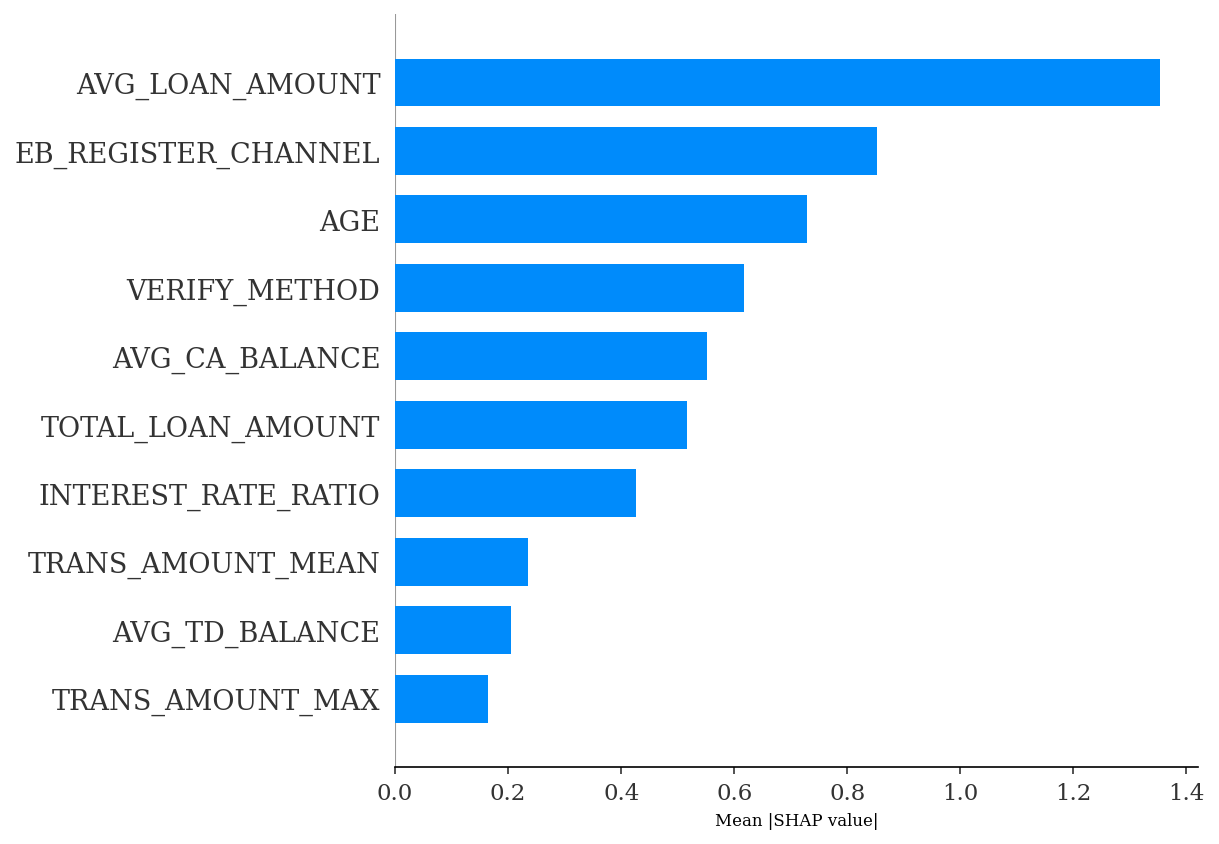


Saving SHAP beeswarm plot:
/content/drive/MyDrive/Fintect/landmark_180d_training_results/full_metrics_shap/Fig_Landmark180D_SHAP_Beeswarm_600dpi.png


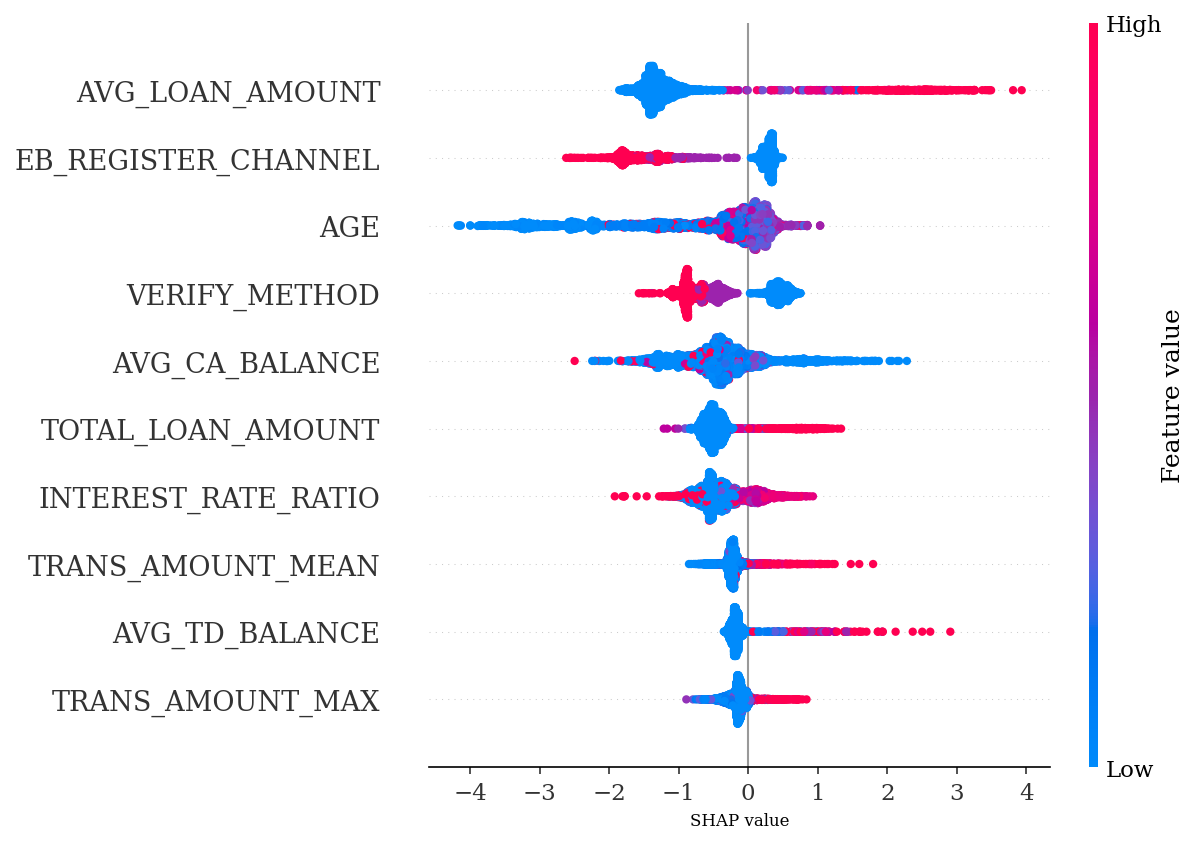


Saving COUNT_CA_ACCT dependence plot:
/content/drive/MyDrive/Fintect/landmark_180d_training_results/full_metrics_shap/Fig_Landmark180D_COUNT_CA_ACCT_Dependence_600dpi.png


<Figure size 525x450 with 0 Axes>

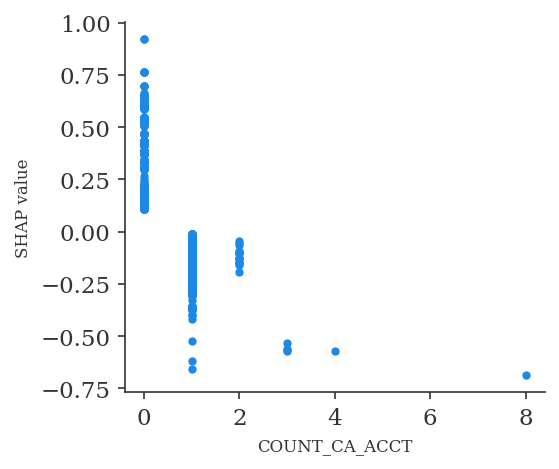


LANDMARK 180-DAY XGBOOST + ROS + SHAP COMPLETED

Performance table:
                  Metric      Test set 5-fold CV (mean ± SD)
                     AUC         0.939       0.9463 ± 0.0041
            KS statistic         0.738       0.7587 ± 0.0196
                  Recall         0.711       0.7518 ± 0.0206
               Precision         0.360       0.3753 ± 0.0127
                F1-score         0.478       0.5005 ± 0.0104
                Accuracy         0.944       0.9457 ± 0.0026
             Brier score         0.046       0.0445 ± 0.0022
 Precision@10% / Lift@D1 0.275 / 7.615                     —
             Capture@10%         0.762                     —
Precision@20% / Lift@20% 0.162 / 4.493                     —
             Capture@20%         0.899                     —
Precision@30% / Lift@30% 0.114 / 3.164                     —
             Capture@30%         0.949                     —

Top five SHAP features:
 RANK             FEATURE  MEAN_ABS_SHAP  MEAN_SIGNE

In [ ]:
# ============================================================
# ETB LANDMARK 180-DAY
# XGBOOST + RANDOM OVERSAMPLING + SHAP
#
# Outputs:
#   1. Five-fold cross-validation metrics
#   2. Holdout test metrics
#   3. Ranking metrics at Top 10%, 20%, 30%
#   4. Publication-style performance table
#   5. SHAP global importance
#   6. SHAP bar plot
#   7. SHAP beeswarm plot
#   8. COUNT_CA_ACCT dependence plot
#
# GOOGLE COLAB — COPY AND RUN DIRECTLY
# ============================================================

# Bỏ dấu # ở dòng dưới nếu Colab chưa có thư viện:
# !pip install -q shap xgboost imbalanced-learn openpyxl

import os
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import shap

from google.colab import drive

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. MOUNT GOOGLE DRIVE
# ============================================================

drive.mount(
    "/content/drive",
    force_remount=False
)

MYDRIVE_ROOT = "/content/drive/MyDrive"

if not Path(MYDRIVE_ROOT).is_dir():
    raise RuntimeError(
        "Không truy cập được Google Drive tại:\n"
        f"{MYDRIVE_ROOT}"
    )


# ============================================================
# 2. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_180d",
    "final_dataset_landmark_180d_no_auto_job.csv"
)

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_180d_training_results",
    "full_metrics_shap"
)

# Luôn tạo đầy đủ thư mục cha và thư mục output.
Path(OUTPUT_DIR).mkdir(
    parents=True,
    exist_ok=True
)

ID_COL = "CUSTOMER_NUMBER"
TARGET_COL = "TARGET_180D"

TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

DECISION_THRESHOLD = 0.50

SHAP_SAMPLE_SIZE = 5000
MAX_SHAP_DISPLAY = 10

MODEL_NAME = "XGBoost + RandomOverSampling (ROS)"

print("=" * 80)
print("LANDMARK 180-DAY CONFIGURATION")
print("=" * 80)

print("\nInput file:")
print(INPUT_FILE)

print("\nInput exists:")
print(Path(INPUT_FILE).is_file())

print("\nOutput directory:")
print(OUTPUT_DIR)

print("\nOutput directory exists:")
print(Path(OUTPUT_DIR).is_dir())

if not Path(INPUT_FILE).is_file():
    raise FileNotFoundError(
        "Không tìm thấy file đầu vào:\n"
        f"{INPUT_FILE}\n\n"
        "Hãy kiểm tra lại tên thư mục hoặc chạy bước tạo "
        "final dataset Landmark 180 ngày trước."
    )


# ============================================================
# 3. EXCLUDED COLUMNS
# ============================================================

EXCLUDE_COLS = [
    ID_COL,
    TARGET_COL,

    "COUNT_CREDITCARD",
    "TOTAL_CARD",
    "RAW_TARGET",
    "TARGET",
    "TARGET_MONTH",

    "FIRST_CARD_MONTH",
    "FIRST_OBS_MONTH",
    "LAST_OBS_MONTH",

    "RELATIONSHIP_START_DATE",
    "LANDMARK_DATE",
    "FEATURE_CUTOFF_DATE",
    "CLIENT_CREATE_DATE",
    "HAS_30D_FOLLOWUP",
    "EARLY_CARD_30D",

    # Loại thêm tên cột của các cửa sổ khác nếu vô tình còn trong file.
    "HAS_60D_FOLLOWUP",
    "EARLY_CARD_60D",
    "HAS_90D_FOLLOWUP",
    "EARLY_CARD_90D",
    "HAS_180D_FOLLOWUP",
    "EARLY_CARD_180D",

    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET"
]


# ============================================================
# 4. IEEE FIGURE SETTINGS
# ============================================================

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.0,
    "figure.dpi": 150,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ============================================================
# 5. HELPER FUNCTIONS
# ============================================================

def ensure_output_dir():
    """
    Tạo lại thư mục output nếu thư mục bị mất hoặc Drive
    vừa được kết nối lại.
    """
    Path(OUTPUT_DIR).mkdir(
        parents=True,
        exist_ok=True
    )

    if not Path(OUTPUT_DIR).is_dir():
        raise RuntimeError(
            "Không thể tạo thư mục output:\n"
            f"{OUTPUT_DIR}"
        )


def get_xgb_model():
    """
    Tạo XGBoost với cùng cấu hình cho CV và mô hình cuối.
    """
    return XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        max_bin=256,
        random_state=MODEL_RANDOM_STATE,
        n_jobs=2
    )


def standardize_customer_id(series):
    """
    Chuẩn hóa CUSTOMER_NUMBER thành chuỗi.
    """
    result = (
        series
        .astype("string")
        .str.strip()
        .str.replace(
            r"\.0$",
            "",
            regex=True
        )
    )

    invalid_values = [
        "",
        "NAN",
        "<NA>",
        "NONE",
        "NULL"
    ]

    return result.mask(
        result.str.upper().isin(invalid_values),
        pd.NA
    )


def require_columns(
    dataframe,
    required_columns,
    table_name
):
    """
    Kiểm tra các cột bắt buộc.
    """
    missing_columns = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing_columns:
        raise ValueError(
            f"{table_name} thiếu các cột:\n"
            f"{missing_columns}\n\n"
            f"Các cột hiện có:\n"
            f"{dataframe.columns.tolist()}"
        )


def fit_preprocess(
    X_train_raw,
    X_valid_raw,
    categorical_columns
):
    """
    Fit preprocessing chỉ trên training subset.

    - Ordinal encoding cho biến phân loại.
    - Unknown category = -1.
    - Median imputation cho tất cả feature sau encoding.
    """
    X_train_work = X_train_raw.copy()
    X_valid_work = X_valid_raw.copy()

    encoder = None

    if categorical_columns:

        for column in categorical_columns:

            X_train_work[column] = (
                X_train_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

            X_valid_work[column] = (
                X_valid_work[column]
                .astype("string")
                .fillna("UNKNOWN")
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
            dtype=np.float32
        )

        X_train_work[categorical_columns] = (
            encoder.fit_transform(
                X_train_work[categorical_columns]
            )
        )

        X_valid_work[categorical_columns] = (
            encoder.transform(
                X_valid_work[categorical_columns]
            )
        )

    for column in X_train_work.columns:

        X_train_work[column] = pd.to_numeric(
            X_train_work[column],
            errors="coerce"
        )

        X_valid_work[column] = pd.to_numeric(
            X_valid_work[column],
            errors="coerce"
        )

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_processed = (
        imputer
        .fit_transform(X_train_work)
        .astype(np.float32)
    )

    X_valid_processed = (
        imputer
        .transform(X_valid_work)
        .astype(np.float32)
    )

    return (
        X_train_processed,
        X_valid_processed,
        imputer,
        encoder
    )


def calculate_ks(
    y_true,
    y_probability
):
    """
    Tính Kolmogorov-Smirnov statistic.
    """
    fpr, tpr, _ = roc_curve(
        y_true,
        y_probability
    )

    return float(
        np.max(tpr - fpr)
    )


def calculate_ranking_metrics(
    y_true,
    y_probability,
    top_rates=(0.10, 0.20, 0.30)
):
    """
    Tính Precision, Lift và Capture Rate tại Top K%.
    """
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n_customers = len(ranking)
    base_rate = float(ranking["Y_TRUE"].mean())
    total_positives = int(ranking["Y_TRUE"].sum())

    rows = []

    for rate in top_rates:

        top_n = max(
            1,
            int(np.ceil(n_customers * rate))
        )

        top_group = ranking.iloc[:top_n]

        precision_at_k = float(
            top_group["Y_TRUE"].mean()
        )

        captured_positives = int(
            top_group["Y_TRUE"].sum()
        )

        lift_at_k = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        capture_rate = (
            captured_positives / total_positives
            if total_positives > 0
            else np.nan
        )

        rows.append({
            "TOP_K": f"Top {int(rate * 100)}%",
            "TOP_RATE": float(rate),
            "CUSTOMERS": int(top_n),
            "PRECISION": precision_at_k,
            "LIFT": lift_at_k,
            "CAPTURED_POSITIVES": captured_positives,
            "CAPTURE_RATE": capture_rate
        })

    return pd.DataFrame(rows)


def create_decile_table(
    y_true,
    y_probability
):
    """
    Tạo bảng decile D1–D10.
    """
    ranking = pd.DataFrame({
        "Y_TRUE": np.asarray(y_true),
        "Y_PROB": np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    ranking["DECILE"] = pd.qcut(
        np.arange(len(ranking)),
        q=10,
        labels=[
            f"D{i}"
            for i in range(1, 11)
        ]
    )

    result = (
        ranking
        .groupby(
            "DECILE",
            observed=False
        )
        .agg(
            CUSTOMERS=("Y_TRUE", "count"),
            POSITIVES=("Y_TRUE", "sum"),
            ADOPTION_RATE=("Y_TRUE", "mean"),
            AVG_PRED_PROB=("Y_PROB", "mean")
        )
        .reset_index()
    )

    base_rate = float(
        ranking["Y_TRUE"].mean()
    )

    result["LIFT"] = (
        result["ADOPTION_RATE"] / base_rate
        if base_rate > 0
        else np.nan
    )

    return result


def get_ranking_row(
    ranking_table,
    top_rate
):
    """
    Lấy hàng ranking tương ứng với TOP_RATE.
    """
    matched_rows = ranking_table.loc[
        np.isclose(
            ranking_table["TOP_RATE"],
            top_rate,
            atol=1e-8
        )
    ]

    if matched_rows.empty:
        raise ValueError(
            f"Không tìm thấy ranking metric cho "
            f"Top {int(top_rate * 100)}%."
        )

    return matched_rows.iloc[0]


def format_test_metric(
    value,
    decimals=3
):
    return f"{float(value):.{decimals}f}"


def format_cv_metric(
    values,
    decimals=4
):
    mean_value = float(values.mean())
    std_value = float(values.std(ddof=1))

    return (
        f"{mean_value:.{decimals}f} ± "
        f"{std_value:.{decimals}f}"
    )


# ============================================================
# 6. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

require_columns(
    df,
    [
        ID_COL,
        TARGET_COL
    ],
    "Landmark 180-day dataset"
)

df[ID_COL] = standardize_customer_id(
    df[ID_COL]
)

df[TARGET_COL] = pd.to_numeric(
    df[TARGET_COL],
    errors="coerce"
)

df = df.dropna(
    subset=[
        ID_COL,
        TARGET_COL
    ]
).copy()

if not df[TARGET_COL].isin([0, 1]).all():
    raise ValueError(
        "TARGET_180D phải chỉ gồm 0 và 1."
    )

df[TARGET_COL] = (
    df[TARGET_COL]
    .astype(np.int8)
)

duplicate_count = int(
    df[ID_COL]
    .duplicated()
    .sum()
)

if duplicate_count > 0:
    raise ValueError(
        f"Có {duplicate_count:,} khách hàng bị trùng."
    )

df = df.replace(
    [
        "",
        " ",
        "NA",
        "N/A",
        "na",
        "null",
        "NULL",
        "None",
        "none"
    ],
    np.nan
)

df = (
    df
    .sort_values(ID_COL)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DATASET")
print("=" * 80)

print("Shape:", df.shape)

print("\nTarget distribution:")
print(
    df[TARGET_COL]
    .value_counts()
    .sort_index()
)

print(
    "\nPositive rate:",
    f"{df[TARGET_COL].mean() * 100:.4f}%"
)


# ============================================================
# 7. PREPARE FEATURES
# ============================================================

feature_cols = [
    column
    for column in df.columns
    if column not in EXCLUDE_COLS
]

if not feature_cols:
    raise ValueError(
        "Không còn feature nào sau khi loại EXCLUDE_COLS."
    )

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()
customer_ids = df[ID_COL].copy()

# Nhận diện cột text nhưng thực chất là numeric.
for column in X.columns:

    is_text = (
        pd.api.types.is_object_dtype(X[column])
        or pd.api.types.is_string_dtype(X[column])
        or isinstance(
            X[column].dtype,
            pd.CategoricalDtype
        )
    )

    if is_text:

        converted = pd.to_numeric(
            X[column],
            errors="coerce"
        )

        original_non_null = int(
            X[column].notna().sum()
        )

        converted_non_null = int(
            converted.notna().sum()
        )

        numeric_ratio = (
            converted_non_null / original_non_null
            if original_non_null > 0
            else 0
        )

        if numeric_ratio >= 0.80:
            X[column] = converted
        else:
            X[column] = X[column].astype("string")

categorical_columns = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category"
        ]
    )
    .columns
    .tolist()
)

print(
    "\nNumber of features:",
    len(feature_cols)
)

print("\nFeature list:")

for index, feature in enumerate(
    feature_cols,
    start=1
):
    print(f"{index:02d}. {feature}")

print("\nCategorical columns:")
print(categorical_columns)


# ============================================================
# 8. TRAIN–TEST SPLIT
# ============================================================

all_indices = np.arange(len(df))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=SPLIT_RANDOM_STATE
)

X_train = (
    X.iloc[train_indices]
    .reset_index(drop=True)
)

X_test = (
    X.iloc[test_indices]
    .reset_index(drop=True)
)

y_train = (
    y.iloc[train_indices]
    .reset_index(drop=True)
)

y_test = (
    y.iloc[test_indices]
    .reset_index(drop=True)
)

test_ids = (
    customer_ids.iloc[test_indices]
    .reset_index(drop=True)
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

print(
    "\nTrain positive rate:",
    f"{y_train.mean() * 100:.4f}%"
)

print(
    "Test positive rate:",
    f"{y_test.mean() * 100:.4f}%"
)


# ============================================================
# 9. FIVE-FOLD CROSS-VALIDATION
# ============================================================

stratified_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=MODEL_RANDOM_STATE
)

cv_rows = []

for fold, (
    fold_train_indices,
    fold_valid_indices
) in enumerate(
    stratified_cv.split(
        X_train,
        y_train
    ),
    start=1
):

    print(
        f"\nRunning fold {fold}/{N_SPLITS}..."
    )

    X_fold_train = (
        X_train.iloc[fold_train_indices]
        .copy()
    )

    X_fold_valid = (
        X_train.iloc[fold_valid_indices]
        .copy()
    )

    y_fold_train = (
        y_train.iloc[fold_train_indices]
        .copy()
    )

    y_fold_valid = (
        y_train.iloc[fold_valid_indices]
        .copy()
    )

    (
        X_fold_train_processed,
        X_fold_valid_processed,
        _,
        _
    ) = fit_preprocess(
        X_fold_train,
        X_fold_valid,
        categorical_columns
    )

    ros = RandomOverSampler(
        random_state=MODEL_RANDOM_STATE
    )

    X_fold_ros, y_fold_ros = ros.fit_resample(
        X_fold_train_processed,
        y_fold_train.to_numpy()
    )

    fold_model = get_xgb_model()

    fold_model.fit(
        X_fold_ros,
        y_fold_ros
    )

    y_valid_probability = (
        fold_model
        .predict_proba(
            X_fold_valid_processed
        )[:, 1]
    )

    y_valid_prediction = (
        y_valid_probability
        >= DECISION_THRESHOLD
    ).astype(np.int8)

    fold_result = {
        "FOLD": fold,
        "AUC": roc_auc_score(
            y_fold_valid,
            y_valid_probability
        ),
        "KS": calculate_ks(
            y_fold_valid,
            y_valid_probability
        ),
        "RECALL": recall_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "PRECISION": precision_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_fold_valid,
            y_valid_prediction,
            zero_division=0
        ),
        "ACCURACY": accuracy_score(
            y_fold_valid,
            y_valid_prediction
        ),
        "BRIER": brier_score_loss(
            y_fold_valid,
            y_valid_probability
        )
    }

    cv_rows.append(fold_result)

    print(
        f"AUC={fold_result['AUC']:.4f} | "
        f"KS={fold_result['KS']:.4f} | "
        f"Recall={fold_result['RECALL']:.4f} | "
        f"Precision={fold_result['PRECISION']:.4f} | "
        f"F1={fold_result['F1']:.4f}"
    )

    del fold_model
    del ros
    del X_fold_train_processed
    del X_fold_valid_processed
    del X_fold_ros
    del y_fold_ros

    gc.collect()

cv_results = pd.DataFrame(cv_rows)

cv_metric_columns = [
    "AUC",
    "KS",
    "RECALL",
    "PRECISION",
    "F1",
    "ACCURACY",
    "BRIER"
]

cv_summary = pd.DataFrame([
    {
        "METRIC": metric,
        "MEAN": float(
            cv_results[metric].mean()
        ),
        "STD": float(
            cv_results[metric].std(ddof=1)
        ),
        "MEAN_PLUS_MINUS_SD": (
            f"{cv_results[metric].mean():.4f} ± "
            f"{cv_results[metric].std(ddof=1):.4f}"
        )
    }
    for metric in cv_metric_columns
])

print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

print(
    cv_summary[
        [
            "METRIC",
            "MEAN_PLUS_MINUS_SD"
        ]
    ].to_string(index=False)
)


# ============================================================
# 10. PREPROCESS FULL TRAIN AND TEST
# ============================================================

(
    X_train_processed,
    X_test_processed,
    final_imputer,
    final_encoder
) = fit_preprocess(
    X_train,
    X_test,
    categorical_columns
)


# ============================================================
# 11. RANDOM OVERSAMPLING
# ============================================================

final_ros = RandomOverSampler(
    random_state=MODEL_RANDOM_STATE
)

X_train_ros, y_train_ros = final_ros.fit_resample(
    X_train_processed,
    y_train.to_numpy()
)

print("\n" + "=" * 80)
print("RANDOM OVERSAMPLING")
print("=" * 80)

print("Before ROS:", X_train_processed.shape)
print("After ROS :", X_train_ros.shape)

print("\nClass distribution after ROS:")

print(
    pd.Series(y_train_ros)
    .value_counts()
    .sort_index()
)


# ============================================================
# 12. TRAIN FINAL MODEL
# ============================================================

print("\nTraining final model...")

final_model = get_xgb_model()

final_model.fit(
    X_train_ros,
    y_train_ros
)

print("Final model training completed.")


# ============================================================
# 13. TEST PREDICTIONS AND METRICS
# ============================================================

y_test_probability = (
    final_model
    .predict_proba(
        X_test_processed
    )[:, 1]
)

y_test_prediction = (
    y_test_probability
    >= DECISION_THRESHOLD
).astype(np.int8)

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

test_ks = calculate_ks(
    y_test,
    y_test_probability
)

test_recall = recall_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_precision = precision_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_accuracy = accuracy_score(
    y_test,
    y_test_prediction
)

test_brier = brier_score_loss(
    y_test,
    y_test_probability
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_prediction,
    labels=[0, 1]
).ravel()

print("\n" + "=" * 80)
print("TEST RESULTS")
print("=" * 80)

print(f"AUC       : {test_auc:.6f}")
print(f"KS        : {test_ks:.6f}")
print(f"Recall    : {test_recall:.6f}")
print(f"Precision : {test_precision:.6f}")
print(f"F1        : {test_f1:.6f}")
print(f"Accuracy  : {test_accuracy:.6f}")
print(f"Brier     : {test_brier:.6f}")

print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nClassification report:")

print(
    classification_report(
        y_test,
        y_test_prediction,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 14. RANKING METRICS
# ============================================================

ranking_results = calculate_ranking_metrics(
    y_test,
    y_test_probability
)

decile_table = create_decile_table(
    y_test,
    y_test_probability
)

print("\n" + "=" * 80)
print("RANKING METRICS")
print("=" * 80)

print(
    ranking_results.to_string(index=False)
)

predictions = pd.DataFrame({
    ID_COL: test_ids.to_numpy(),
    "Y_TRUE": y_test.to_numpy(),
    "Y_PROB": np.asarray(y_test_probability),
    "Y_PRED": np.asarray(y_test_prediction)
})

top10 = get_ranking_row(
    ranking_results,
    0.10
)

top20 = get_ranking_row(
    ranking_results,
    0.20
)

top30 = get_ranking_row(
    ranking_results,
    0.30
)


# ============================================================
# 15. PUBLICATION-STYLE PERFORMANCE TABLE
# ============================================================

performance_table = pd.DataFrame([
    {
        "Metric": "AUC",
        "Test set": format_test_metric(test_auc),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["AUC"]
        )
    },
    {
        "Metric": "KS statistic",
        "Test set": format_test_metric(test_ks),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["KS"]
        )
    },
    {
        "Metric": "Recall",
        "Test set": format_test_metric(test_recall),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["RECALL"]
        )
    },
    {
        "Metric": "Precision",
        "Test set": format_test_metric(test_precision),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["PRECISION"]
        )
    },
    {
        "Metric": "F1-score",
        "Test set": format_test_metric(test_f1),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["F1"]
        )
    },
    {
        "Metric": "Accuracy",
        "Test set": format_test_metric(test_accuracy),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["ACCURACY"]
        )
    },
    {
        "Metric": "Brier score",
        "Test set": format_test_metric(test_brier),
        "5-fold CV (mean ± SD)": format_cv_metric(
            cv_results["BRIER"]
        )
    },
    {
        "Metric": "Precision@10% / Lift@D1",
        "Test set": (
            f"{float(top10['PRECISION']):.3f} / "
            f"{float(top10['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@10%",
        "Test set": format_test_metric(
            top10["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@20% / Lift@20%",
        "Test set": (
            f"{float(top20['PRECISION']):.3f} / "
            f"{float(top20['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@20%",
        "Test set": format_test_metric(
            top20["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Precision@30% / Lift@30%",
        "Test set": (
            f"{float(top30['PRECISION']):.3f} / "
            f"{float(top30['LIFT']):.3f}"
        ),
        "5-fold CV (mean ± SD)": "—"
    },
    {
        "Metric": "Capture@30%",
        "Test set": format_test_metric(
            top30["CAPTURE_RATE"]
        ),
        "5-fold CV (mean ± SD)": "—"
    }
])

print("\n" + "=" * 95)
print("PUBLICATION-STYLE PERFORMANCE TABLE")
print("=" * 95)

print(
    performance_table.to_string(index=False)
)


# ============================================================
# 16. PREPARE SHAP SAMPLE
# ============================================================

shap_sample_size = min(
    SHAP_SAMPLE_SIZE,
    len(X_test_processed)
)

random_generator = np.random.default_rng(
    MODEL_RANDOM_STATE
)

shap_indices = random_generator.choice(
    len(X_test_processed),
    size=shap_sample_size,
    replace=False
)

X_shap = pd.DataFrame(
    X_test_processed[shap_indices],
    columns=feature_cols
)

print("\n" + "=" * 80)
print("SHAP ANALYSIS")
print("=" * 80)

print("SHAP sample size:", shap_sample_size)
print("SHAP input shape:", X_shap.shape)


# ============================================================
# 17. CALCULATE SHAP VALUES
# ============================================================

print("\nComputing SHAP values...")

shap_explainer = shap.TreeExplainer(
    final_model
)

shap_values_raw = shap_explainer.shap_values(
    X_shap
)

if isinstance(shap_values_raw, list):
    shap_values = np.asarray(
        shap_values_raw[-1]
    )
else:
    shap_values = np.asarray(
        shap_values_raw
    )

# Một số phiên bản SHAP trả về:
# (samples, features, classes)
if shap_values.ndim == 3:
    shap_values = shap_values[:, :, -1]

if shap_values.shape != X_shap.shape:
    raise ValueError(
        "SHAP shape không khớp dữ liệu:\n"
        f"SHAP shape: {shap_values.shape}\n"
        f"X_SHAP shape: {X_shap.shape}"
    )

if not np.isfinite(shap_values).all():
    raise ValueError(
        "SHAP values có NaN hoặc infinity."
    )

print("SHAP values shape:", shap_values.shape)


# ============================================================
# 18. SHAP GLOBAL IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "FEATURE": feature_cols,
    "MEAN_ABS_SHAP": np.abs(
        shap_values
    ).mean(axis=0),
    "MEAN_SIGNED_SHAP": shap_values.mean(
        axis=0
    )
})

shap_importance = (
    shap_importance
    .sort_values(
        "MEAN_ABS_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.insert(
    0,
    "RANK",
    np.arange(
        1,
        len(shap_importance) + 1
    )
)

top5_shap = (
    shap_importance
    .head(5)
    .copy()
)

count_ca_result = shap_importance.loc[
    shap_importance["FEATURE"]
    .astype(str)
    .str.upper()
    .eq("COUNT_CA_ACCT")
]

if not count_ca_result.empty:

    count_ca_rank = int(
        count_ca_result.iloc[0]["RANK"]
    )

    count_ca_mean_abs_shap = float(
        count_ca_result.iloc[0][
            "MEAN_ABS_SHAP"
        ]
    )

else:
    count_ca_rank = None
    count_ca_mean_abs_shap = None

print("\nTop 10 SHAP features:")

print(
    shap_importance
    .head(10)
    .to_string(index=False)
)

print("\nTop five SHAP features:")

print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)

print("\nCOUNT_CA_ACCT mean absolute SHAP:")
print(count_ca_mean_abs_shap)


# ============================================================
# 19. SHAP BAR PLOT — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_bar_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark180D_SHAP_Bar_600dpi.png"
)

shap_bar_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark180D_SHAP_Bar.pdf"
)

plt.figure(
    figsize=(3.5, 3.0)
)

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "Mean |SHAP value|",
    fontsize=8
)

plt.tight_layout(
    pad=0.3
)

print("\nSaving SHAP bar plot:")
print(shap_bar_png)

plt.savefig(
    shap_bar_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    shap_bar_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 20. SHAP BEESWARM — IEEE SINGLE COLUMN
# ============================================================

ensure_output_dir()

shap_beeswarm_png = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark180D_SHAP_Beeswarm_600dpi.png"
)

shap_beeswarm_pdf = os.path.join(
    OUTPUT_DIR,
    "Fig_Landmark180D_SHAP_Beeswarm.pdf"
)

plt.figure(
    figsize=(3.5, 3.4)
)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=MAX_SHAP_DISPLAY,
    show=False
)

plt.xlabel(
    "SHAP value",
    fontsize=8
)

plt.tight_layout(
    pad=0.3
)

print("\nSaving SHAP beeswarm plot:")
print(shap_beeswarm_png)

plt.savefig(
    shap_beeswarm_png,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.savefig(
    shap_beeswarm_pdf,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()
plt.close()


# ============================================================
# 21. COUNT_CA_ACCT DEPENDENCE PLOT
# ============================================================

count_ca_png = None
count_ca_pdf = None

if "COUNT_CA_ACCT" in feature_cols:

    ensure_output_dir()

    count_ca_png = os.path.join(
        OUTPUT_DIR,
        "Fig_Landmark180D_COUNT_CA_ACCT_Dependence_600dpi.png"
    )

    count_ca_pdf = os.path.join(
        OUTPUT_DIR,
        "Fig_Landmark180D_COUNT_CA_ACCT_Dependence.pdf"
    )

    plt.figure(
        figsize=(3.5, 3.0)
    )

    shap.dependence_plot(
        "COUNT_CA_ACCT",
        shap_values,
        X_shap,
        interaction_index=None,
        show=False
    )

    plt.gcf().set_size_inches(
        3.5,
        3.0
    )

    plt.xlabel(
        "COUNT_CA_ACCT",
        fontsize=8
    )

    plt.ylabel(
        "SHAP value",
        fontsize=8
    )

    plt.tight_layout(
        pad=0.3
    )

    print("\nSaving COUNT_CA_ACCT dependence plot:")
    print(count_ca_png)

    plt.savefig(
        count_ca_png,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.savefig(
        count_ca_pdf,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close()

else:
    print(
        "\nCOUNT_CA_ACCT không có trong feature list; "
        "bỏ qua dependence plot."
    )


# ============================================================
# 22. COMPLETE MACHINE-READABLE RESULT TABLE
# ============================================================

final_results = pd.DataFrame([{
    "MODEL": MODEL_NAME,
    "LANDMARK_DAYS": LANDMARK_DAYS,

    "N_CUSTOMERS": len(df),
    "N_TRAIN": len(X_train),
    "N_TEST": len(X_test),
    "N_FEATURES": len(feature_cols),

    "BASE_RATE": float(y.mean()),

    "CV_AUC_MEAN": float(
        cv_results["AUC"].mean()
    ),
    "CV_AUC_STD": float(
        cv_results["AUC"].std(ddof=1)
    ),

    "CV_KS_MEAN": float(
        cv_results["KS"].mean()
    ),
    "CV_KS_STD": float(
        cv_results["KS"].std(ddof=1)
    ),

    "CV_RECALL_MEAN": float(
        cv_results["RECALL"].mean()
    ),
    "CV_RECALL_STD": float(
        cv_results["RECALL"].std(ddof=1)
    ),

    "CV_PRECISION_MEAN": float(
        cv_results["PRECISION"].mean()
    ),
    "CV_PRECISION_STD": float(
        cv_results["PRECISION"].std(ddof=1)
    ),

    "CV_F1_MEAN": float(
        cv_results["F1"].mean()
    ),
    "CV_F1_STD": float(
        cv_results["F1"].std(ddof=1)
    ),

    "CV_ACCURACY_MEAN": float(
        cv_results["ACCURACY"].mean()
    ),
    "CV_ACCURACY_STD": float(
        cv_results["ACCURACY"].std(ddof=1)
    ),

    "CV_BRIER_MEAN": float(
        cv_results["BRIER"].mean()
    ),
    "CV_BRIER_STD": float(
        cv_results["BRIER"].std(ddof=1)
    ),

    "TEST_AUC": float(test_auc),
    "TEST_KS": float(test_ks),
    "TEST_RECALL": float(test_recall),
    "TEST_PRECISION": float(test_precision),
    "TEST_F1": float(test_f1),
    "TEST_ACCURACY": float(test_accuracy),
    "TEST_BRIER": float(test_brier),

    "TN": int(tn),
    "FP": int(fp),
    "FN": int(fn),
    "TP": int(tp),

    "PRECISION_AT_10": float(
        top10["PRECISION"]
    ),
    "LIFT_AT_10": float(
        top10["LIFT"]
    ),
    "CAPTURE_RATE_AT_10": float(
        top10["CAPTURE_RATE"]
    ),

    "PRECISION_AT_20": float(
        top20["PRECISION"]
    ),
    "LIFT_AT_20": float(
        top20["LIFT"]
    ),
    "CAPTURE_RATE_AT_20": float(
        top20["CAPTURE_RATE"]
    ),

    "PRECISION_AT_30": float(
        top30["PRECISION"]
    ),
    "LIFT_AT_30": float(
        top30["LIFT"]
    ),
    "CAPTURE_RATE_AT_30": float(
        top30["CAPTURE_RATE"]
    ),

    "TOP_SHAP_FEATURE": str(
        top5_shap.iloc[0]["FEATURE"]
    ),

    "COUNT_CA_ACCT_SHAP_RANK": (
        count_ca_rank
    ),

    "COUNT_CA_ACCT_MEAN_ABS_SHAP": (
        count_ca_mean_abs_shap
    )
}])


# ============================================================
# 23. SAVE CSV OUTPUTS
# ============================================================

ensure_output_dir()

final_results_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_final_results.csv"
)

cv_results_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_cross_validation_results.csv"
)

cv_summary_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_cv_mean_sd.csv"
)

ranking_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_ranking_metrics.csv"
)

decile_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_decile_table.csv"
)

predictions_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_test_predictions.csv"
)

performance_table_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_publication_performance_table.csv"
)

shap_importance_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_shap_global_importance.csv"
)

top5_shap_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_shap_top5.csv"
)

final_results.to_csv(
    final_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_results.to_csv(
    cv_results_file,
    index=False,
    encoding="utf-8-sig"
)

cv_summary.to_csv(
    cv_summary_file,
    index=False,
    encoding="utf-8-sig"
)

ranking_results.to_csv(
    ranking_file,
    index=False,
    encoding="utf-8-sig"
)

decile_table.to_csv(
    decile_file,
    index=False,
    encoding="utf-8-sig"
)

predictions.to_csv(
    predictions_file,
    index=False,
    encoding="utf-8-sig"
)

performance_table.to_csv(
    performance_table_file,
    index=False,
    encoding="utf-8-sig"
)

shap_importance.to_csv(
    shap_importance_file,
    index=False,
    encoding="utf-8-sig"
)

top5_shap.to_csv(
    top5_shap_file,
    index=False,
    encoding="utf-8-sig"
)


# ============================================================
# 24. SAVE FORMATTED EXCEL
# ============================================================

ensure_output_dir()

excel_file = os.path.join(
    OUTPUT_DIR,
    "landmark180d_xgboost_ros_metrics_shap.xlsx"
)

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    final_results.to_excel(
        writer,
        sheet_name="Final results",
        index=False
    )

    performance_table.to_excel(
        writer,
        sheet_name="Performance table",
        index=False
    )

    cv_results.to_excel(
        writer,
        sheet_name="Cross validation",
        index=False
    )

    cv_summary.to_excel(
        writer,
        sheet_name="CV mean SD",
        index=False
    )

    ranking_results.to_excel(
        writer,
        sheet_name="Ranking",
        index=False
    )

    decile_table.to_excel(
        writer,
        sheet_name="Deciles",
        index=False
    )

    predictions.to_excel(
        writer,
        sheet_name="Test predictions",
        index=False
    )

    shap_importance.to_excel(
        writer,
        sheet_name="SHAP importance",
        index=False
    )

    top5_shap.to_excel(
        writer,
        sheet_name="SHAP top 5",
        index=False
    )

    performance_sheet = writer.sheets[
        "Performance table"
    ]

    performance_sheet.freeze_panes = "A2"

    performance_sheet.column_dimensions["A"].width = 32
    performance_sheet.column_dimensions["B"].width = 20
    performance_sheet.column_dimensions["C"].width = 28

    for cell in performance_sheet[1]:

        cell.font = cell.font.copy(
            bold=True
        )

        cell.alignment = cell.alignment.copy(
            horizontal="center",
            vertical="center"
        )

    for row in performance_sheet.iter_rows(
        min_row=2,
        max_row=performance_sheet.max_row,
        min_col=2,
        max_col=3
    ):

        for cell in row:

            cell.alignment = cell.alignment.copy(
                horizontal="center",
                vertical="center"
            )


# ============================================================
# 25. FINAL REPORT
# ============================================================

print("\n" + "=" * 95)
print("LANDMARK 180-DAY XGBOOST + ROS + SHAP COMPLETED")
print("=" * 95)

print("\nPerformance table:")

print(
    performance_table.to_string(index=False)
)

print("\nTop five SHAP features:")

print(
    top5_shap[
        [
            "RANK",
            "FEATURE",
            "MEAN_ABS_SHAP",
            "MEAN_SIGNED_SHAP"
        ]
    ].to_string(index=False)
)

print("\nCOUNT_CA_ACCT SHAP rank:")
print(count_ca_rank)

print("\nSaved Excel:")
print(excel_file)

print("\nSHAP bar figure:")
print(shap_bar_png)

print("\nSHAP beeswarm figure:")
print(shap_beeswarm_png)

if count_ca_png is not None:
    print("\nCOUNT_CA_ACCT dependence figure:")
    print(count_ca_png)

print("\nSaved output directory:")
print(OUTPUT_DIR)

print("\nOutput directory exists:")
print(Path(OUTPUT_DIR).is_dir())

print("\nAll files currently saved in output directory:")

for saved_file in sorted(
    Path(OUTPUT_DIR).glob("*")
):
    print(saved_file.name)

TRAINING NOSAMPLING + XGBOOST

In [ ]:
# ============================================================
# MOUNT GOOGLE DRIVE FOR 180D
# ============================================================

from google.colab import drive
import os
from pathlib import Path

MOUNT_POINT = "/content/mydrive180"

drive.mount(
    MOUNT_POINT,
    force_remount=True
)

MYDRIVE_ROOT = os.path.join(
    MOUNT_POINT,
    "MyDrive"
)

INPUT_FILE = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "final_landmark_180d",
    "final_dataset_landmark_180d_no_auto_job.csv"
)

OUTPUT_DIR = os.path.join(
    MYDRIVE_ROOT,
    "Fintect",
    "landmark_180d_training_results",
    "XGBoost_NoSampling"
)

Path(
    OUTPUT_DIR
).mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 90)
print("180D DRIVE CHECK")
print("=" * 90)

print("\nMYDRIVE_ROOT:")
print(MYDRIVE_ROOT)

print("\nINPUT_FILE:")
print(INPUT_FILE)

print("\nINPUT EXISTS:")
print(os.path.isfile(INPUT_FILE))

print("\nOUTPUT_DIR:")
print(OUTPUT_DIR)

if not os.path.isfile(INPUT_FILE):
    raise FileNotFoundError(
        "Không tìm thấy file 180D:\n"
        f"{INPUT_FILE}"
    )

print("\n✓ Đã tìm thấy file 180D.")
print("✓ Có thể chạy XGBoost + No Sampling.")

Mounted at /content/mydrive180
180D DRIVE CHECK

MYDRIVE_ROOT:
/content/mydrive180/MyDrive

INPUT_FILE:
/content/mydrive180/MyDrive/Fintect/final_landmark_180d/final_dataset_landmark_180d_no_auto_job.csv

INPUT EXISTS:
True

OUTPUT_DIR:
/content/mydrive180/MyDrive/Fintect/landmark_180d_training_results/XGBoost_NoSampling

✓ Đã tìm thấy file 180D.
✓ Có thể chạy XGBoost + No Sampling.


In [ ]:
# ============================================================
# FLDC 180D — XGBOOST + NO SAMPLING
#
# Yêu cầu đã có từ cell trước:
#   INPUT_FILE
#   OUTPUT_DIR
#
# Thực hiện:
#   1. Load dataset
#   2. Xác định target
#   3. Loại biến leakage / audit
#   4. Train-test split 80/20 stratified
#   5. Preprocessing
#   6. 5-fold CV
#   7. Train final XGBoost + No Sampling
#   8. Test metrics
#   9. Ranking Top 10/20/30
# ============================================================


# ============================================================
# 0. IMPORT
# ============================================================

import os
import gc
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURATION
# ============================================================

LANDMARK_DAYS = 180

TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 42
MODEL_RANDOM_STATE = 42

DECISION_THRESHOLD = 0.50

MODEL_NAME = "XGBoost + No Sampling"


# ============================================================
# 2. XGBOOST PARAMETERS
# ============================================================

XGB_PARAMS = {

    "n_estimators": 300,

    "max_depth": 6,

    "learning_rate": 0.05,

    "subsample": 0.8,

    "colsample_bytree": 0.8,

    "objective": "binary:logistic",

    "eval_metric": "logloss",

    "tree_method": "hist",

    "max_bin": 256,

    "random_state": MODEL_RANDOM_STATE,

    "n_jobs": 2
}


print("=" * 90)
print("FLDC 180D — XGBOOST + NO SAMPLING")
print("=" * 90)

print("\nXGBoost configuration:")

for key, value in XGB_PARAMS.items():
    print(
        f"{key:22s}: {value}"
    )

print("-" * 90)
print("RandomOverSampler      : NO")
print("SMOTE                  : NO")
print("Borderline-SMOTE       : NO")
print("ADASYN                 : NO")
print("scale_pos_weight       : NOT USED")
print("class_weight           : NOT USED")
print("=" * 90)


# ============================================================
# 3. HELPER FUNCTIONS
# ============================================================

def get_xgb_model():

    return XGBClassifier(
        **XGB_PARAMS
    )


def calculate_ks(
    y_true,
    y_probability
):

    fpr, tpr, _ = roc_curve(
        y_true,
        y_probability
    )

    return float(
        np.max(
            tpr - fpr
        )
    )


def preprocess_train_valid(
    X_train_raw,
    X_valid_raw,
    categorical_cols
):

    X_train_work = X_train_raw.copy()
    X_valid_work = X_valid_raw.copy()

    encoder = None

    # --------------------------------------------------------
    # Categorical encoding
    # --------------------------------------------------------

    if categorical_cols:

        for col in categorical_cols:

            X_train_work[col] = (
                X_train_work[col]
                .astype("string")
                .fillna("UNKNOWN")
            )

            X_valid_work[col] = (
                X_valid_work[col]
                .astype("string")
                .fillna("UNKNOWN")
            )

        encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
            encoded_missing_value=-1,
            dtype=np.float32
        )

        X_train_work[
            categorical_cols
        ] = encoder.fit_transform(
            X_train_work[
                categorical_cols
            ]
        )

        X_valid_work[
            categorical_cols
        ] = encoder.transform(
            X_valid_work[
                categorical_cols
            ]
        )


    # --------------------------------------------------------
    # Force numeric
    # --------------------------------------------------------

    for col in X_train_work.columns:

        X_train_work[col] = pd.to_numeric(
            X_train_work[col],
            errors="coerce"
        )

        X_valid_work[col] = pd.to_numeric(
            X_valid_work[col],
            errors="coerce"
        )


    # --------------------------------------------------------
    # Imputation
    # --------------------------------------------------------

    imputer = SimpleImputer(
        strategy="median"
    )

    X_train_prep = (
        imputer
        .fit_transform(
            X_train_work
        )
        .astype(np.float32)
    )

    X_valid_prep = (
        imputer
        .transform(
            X_valid_work
        )
        .astype(np.float32)
    )

    return (
        X_train_prep,
        X_valid_prep,
        imputer,
        encoder
    )


def calculate_ranking_metrics(
    y_true,
    y_probability,
    top_rates=(0.10, 0.20, 0.30)
):

    ranking = pd.DataFrame({
        "Y_TRUE":
            np.asarray(y_true),

        "Y_PROB":
            np.asarray(y_probability)
    })

    ranking = (
        ranking
        .sort_values(
            "Y_PROB",
            ascending=False
        )
        .reset_index(drop=True)
    )

    n = len(ranking)

    base_rate = float(
        ranking[
            "Y_TRUE"
        ].mean()
    )

    total_positive = int(
        ranking[
            "Y_TRUE"
        ].sum()
    )

    rows = []

    for rate in top_rates:

        top_n = max(
            1,
            int(
                np.ceil(
                    n * rate
                )
            )
        )

        top_df = (
            ranking.iloc[:top_n]
        )

        precision_at_k = float(
            top_df[
                "Y_TRUE"
            ].mean()
        )

        captured_positive = int(
            top_df[
                "Y_TRUE"
            ].sum()
        )

        lift_at_k = (
            precision_at_k / base_rate
            if base_rate > 0
            else np.nan
        )

        capture_rate = (
            captured_positive / total_positive
            if total_positive > 0
            else np.nan
        )

        rows.append({

            "TOP_K":
                f"Top {int(rate * 100)}%",

            "TOP_RATE":
                rate,

            "CUSTOMERS":
                top_n,

            "PRECISION":
                precision_at_k,

            "LIFT":
                lift_at_k,

            "CAPTURED_POSITIVES":
                captured_positive,

            "CAPTURE_RATE":
                capture_rate
        })

    return pd.DataFrame(
        rows
    )


# ============================================================
# 4. LOAD DATA
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    low_memory=False
)

df.columns = (
    df.columns
    .astype(str)
    .str.strip()
    .str.upper()
)


print("\n" + "=" * 90)
print("DATASET")
print("=" * 90)

print(
    "Shape:",
    df.shape
)

print(
    "\nColumns:"
)

print(
    df.columns.tolist()
)


# ============================================================
# 5. FIND TARGET
# ============================================================

TARGET_CANDIDATES = [

    "TARGET_180D",

    "TARGET",

    "LABEL",

    "COUNT_CREDITCARD"
]


TARGET_COL = next(
    (
        col
        for col in TARGET_CANDIDATES
        if col in df.columns
    ),
    None
)


if TARGET_COL is None:

    raise ValueError(
        "Không tìm thấy target.\n"
        f"Columns hiện tại:\n{df.columns.tolist()}"
    )


print(
    "\nTarget column:",
    TARGET_COL
)


# ============================================================
# 6. CLEAN TARGET
# ============================================================

df[
    TARGET_COL
] = pd.to_numeric(
    df[
        TARGET_COL
    ],
    errors="coerce"
)

df = (
    df
    .dropna(
        subset=[
            TARGET_COL
        ]
    )
    .copy()
)

unique_target = sorted(
    df[
        TARGET_COL
    ]
    .unique()
    .tolist()
)

print(
    "Unique target values:",
    unique_target
)

if not set(
    unique_target
).issubset(
    {0, 1}
):

    raise ValueError(
        "Target không phải binary 0/1."
    )

df[
    TARGET_COL
] = (
    df[
        TARGET_COL
    ]
    .astype(np.int8)
)


print(
    "\nRecords:",
    f"{len(df):,}"
)

print(
    "Positive cases:",
    f"{int(df[TARGET_COL].sum()):,}"
)

print(
    "Base rate:",
    f"{df[TARGET_COL].mean():.4%}"
)


# ============================================================
# 7. EXCLUDE NON-MODEL / LEAKAGE VARIABLES
# ============================================================

EXCLUDE_COLS = [

    TARGET_COL,

    # IDs
    "CUSTOMER_NUMBER",
    "CUSTOMER_ID",
    "NCODPERS",

    # Dates
    "CIF_OPEN_DATE",
    "CARD_OPEN_DATE",
    "FECHA_ALTA",
    "FECHA_DATO",
    "CUTOFF_DATE",
    "FEATURE_CUTOFF_DATE",
    "OBSERVATION_END_DATE",
    "LAST_SNAPSHOT_DATE",
    "LAST_FEATURE_SNAPSHOT",
    "FIRST_CARD_DATE",
    "FIRST_CARD_DATE_AFTER_CUTOFF",

    # Window audit
    "OBSERVED_FEATURE_DAYS",
    "N_FEATURE_SNAPSHOTS",
    "TENURE_AT_CUTOFF",
    "TENURE_DAYS_AT_TARGET",

    # Leakage / label
    "IND_TJCR_FIN_ULT1",
    "RAW_TARGET"
]


feature_cols = [

    col

    for col in df.columns

    if col not in EXCLUDE_COLS
]


if not feature_cols:

    raise ValueError(
        "Không còn feature sau khi loại leakage columns."
    )


X = (
    df[
        feature_cols
    ]
    .copy()
)

y = (
    df[
        TARGET_COL
    ]
    .copy()
)


print(
    "\nNumber of features:",
    len(feature_cols)
)

print(
    "\nFeatures:"
)

for i, col in enumerate(
    feature_cols,
    start=1
):

    print(
        f"{i:02d}. {col}"
    )


# ============================================================
# 8. DETECT CATEGORICAL
# ============================================================

for col in X.columns:

    is_text = (
        pd.api.types.is_object_dtype(
            X[col]
        )
        or
        pd.api.types.is_string_dtype(
            X[col]
        )
        or
        isinstance(
            X[col].dtype,
            pd.CategoricalDtype
        )
    )

    if is_text:

        converted = pd.to_numeric(
            X[col],
            errors="coerce"
        )

        original_non_null = int(
            X[col]
            .notna()
            .sum()
        )

        converted_non_null = int(
            converted
            .notna()
            .sum()
        )

        numeric_ratio = (
            converted_non_null / original_non_null
            if original_non_null > 0
            else 0
        )

        if numeric_ratio >= 0.80:

            X[col] = converted

        else:

            X[col] = (
                X[col]
                .astype("string")
            )


categorical_cols = (
    X.select_dtypes(
        include=[
            "object",
            "string",
            "category"
        ]
    )
    .columns
    .tolist()
)


print(
    "\nCategorical columns:"
)

print(
    categorical_cols
)


# ============================================================
# 9. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = (
    train_test_split(

        X,

        y,

        test_size=
            TEST_SIZE,

        stratify=
            y,

        random_state=
            SPLIT_RANDOM_STATE
    )
)


X_train = (
    X_train
    .reset_index(drop=True)
)

X_test = (
    X_test
    .reset_index(drop=True)
)

y_train = (
    y_train
    .reset_index(drop=True)
)

y_test = (
    y_test
    .reset_index(drop=True)
)


print("\n" + "=" * 90)
print("TRAIN / TEST SPLIT")
print("=" * 90)

print(
    "Train:",
    X_train.shape
)

print(
    "Test :",
    X_test.shape
)

print(
    "Train base rate:",
    f"{y_train.mean():.4%}"
)

print(
    "Test base rate:",
    f"{y_test.mean():.4%}"
)


# ============================================================
# 10. FIVE-FOLD CV — NO SAMPLING
# ============================================================

cv = StratifiedKFold(
    n_splits=
        N_SPLITS,

    shuffle=True,

    random_state=
        MODEL_RANDOM_STATE
)


cv_rows = []


print("\n" + "=" * 90)
print("5-FOLD CV — XGBOOST + NO SAMPLING")
print("=" * 90)


for fold, (
    train_idx,
    valid_idx
) in enumerate(

    cv.split(
        X_train,
        y_train
    ),

    start=1
):


    X_fold_train = (
        X_train.iloc[
            train_idx
        ]
        .copy()
    )

    X_fold_valid = (
        X_train.iloc[
            valid_idx
        ]
        .copy()
    )

    y_fold_train = (
        y_train.iloc[
            train_idx
        ]
        .copy()
    )

    y_fold_valid = (
        y_train.iloc[
            valid_idx
        ]
        .copy()
    )


    (
        X_fold_train_prep,
        X_fold_valid_prep,
        _,
        _
    ) = preprocess_train_valid(

        X_fold_train,

        X_fold_valid,

        categorical_cols
    )


    # --------------------------------------------------------
    # NO SAMPLING
    # --------------------------------------------------------

    fold_model = get_xgb_model()


    fold_model.fit(
        X_fold_train_prep,
        y_fold_train.to_numpy()
    )


    y_valid_prob = (
        fold_model
        .predict_proba(
            X_fold_valid_prep
        )[:, 1]
    )


    y_valid_pred = (
        y_valid_prob
        >=
        DECISION_THRESHOLD
    ).astype(np.int8)


    row = {

        "FOLD":
            fold,

        "AUC":
            roc_auc_score(
                y_fold_valid,
                y_valid_prob
            ),

        "KS":
            calculate_ks(
                y_fold_valid,
                y_valid_prob
            ),

        "ACCURACY":
            accuracy_score(
                y_fold_valid,
                y_valid_pred
            ),

        "RECALL":
            recall_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

        "PRECISION":
            precision_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_fold_valid,
                y_valid_pred,
                zero_division=0
            ),

        "BRIER":
            brier_score_loss(
                y_fold_valid,
                y_valid_prob
            )
    }


    cv_rows.append(
        row
    )


    print(
        f"Fold {fold}: "
        f"AUC={row['AUC']:.4f} | "
        f"KS={row['KS']:.4f} | "
        f"Accuracy={row['ACCURACY']:.4f} | "
        f"Recall={row['RECALL']:.4f} | "
        f"Precision={row['PRECISION']:.4f} | "
        f"F1={row['F1']:.4f} | "
        f"Brier={row['BRIER']:.4f}"
    )


    del fold_model
    del X_fold_train_prep
    del X_fold_valid_prep

    gc.collect()


cv_results = pd.DataFrame(
    cv_rows
)


# ============================================================
# 11. CV SUMMARY
# ============================================================

print("\n" + "=" * 90)
print("CV SUMMARY")
print("=" * 90)


for metric in [
    "AUC",
    "KS",
    "ACCURACY",
    "RECALL",
    "PRECISION",
    "F1",
    "BRIER"
]:

    mean_value = (
        cv_results[
            metric
        ].mean()
    )

    std_value = (
        cv_results[
            metric
        ].std(ddof=1)
    )

    print(
        f"{metric:10s}: "
        f"{mean_value:.4f} ± "
        f"{std_value:.4f}"
    )


# ============================================================
# 12. PREPROCESS FULL TRAIN / TEST
# ============================================================

(
    X_train_prep,
    X_test_prep,
    final_imputer,
    final_encoder
) = preprocess_train_valid(

    X_train,

    X_test,

    categorical_cols
)


print("\n" + "=" * 90)
print("PREPROCESSING COMPLETED")
print("=" * 90)

print(
    "X_train_prep:",
    X_train_prep.shape
)

print(
    "X_test_prep :",
    X_test_prep.shape
)


# ============================================================
# 13. FINAL MODEL — NO SAMPLING
# ============================================================

print("\n" + "=" * 90)
print("FINAL MODEL — XGBOOST + NO SAMPLING")
print("=" * 90)


xgb_no_sampling = get_xgb_model()


xgb_no_sampling.fit(
    X_train_prep,
    y_train.to_numpy()
)


final_model = (
    xgb_no_sampling
)

xgb = (
    xgb_no_sampling
)


print(
    "Final model trained."
)

print(
    "Training rows:",
    f"{len(y_train):,}"
)

print(
    "Training positives:",
    f"{int(y_train.sum()):,}"
)

print(
    "Training base rate:",
    f"{y_train.mean():.4%}"
)


# ============================================================
# 14. HOLDOUT PREDICTIONS
# ============================================================

y_test_probability = (
    final_model
    .predict_proba(
        X_test_prep
    )[:, 1]
    .astype(float)
)


y_test_prediction = (
    y_test_probability
    >=
    DECISION_THRESHOLD
).astype(np.int8)


# Aliases cho fairness/SHAP
y_prob = (
    y_test_probability.copy()
)

y_pred = (
    y_test_prediction.copy()
)


# ============================================================
# 15. HOLDOUT METRICS
# ============================================================

test_auc = roc_auc_score(
    y_test,
    y_test_probability
)

test_ks = calculate_ks(
    y_test,
    y_test_probability
)

test_accuracy = accuracy_score(
    y_test,
    y_test_prediction
)

test_recall = recall_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_precision = precision_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_prediction,
    zero_division=0
)

test_brier = brier_score_loss(
    y_test,
    y_test_probability
)


tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_prediction,
    labels=[0, 1]
).ravel()


print("\n" + "=" * 90)
print("180D HOLDOUT TEST RESULTS")
print("XGBOOST + NO SAMPLING")
print("=" * 90)

print(
    f"AUC       : {test_auc:.6f}"
)

print(
    f"KS        : {test_ks:.6f}"
)

print(
    f"Accuracy  : {test_accuracy:.6f}"
)

print(
    f"Recall    : {test_recall:.6f}"
)

print(
    f"Precision : {test_precision:.6f}"
)

print(
    f"F1        : {test_f1:.6f}"
)

print(
    f"Brier     : {test_brier:.6f}"
)


print("\nConfusion matrix:")

print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)


print("\nClassification report:")

print(
    classification_report(
        y_test,
        y_test_prediction,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. RANKING METRICS
# ============================================================

ranking_results = (
    calculate_ranking_metrics(

        y_test,

        y_test_probability,

        top_rates=(
            0.10,
            0.20,
            0.30
        )
    )
)


print("\n" + "=" * 100)
print("180D RANKING METRICS")
print("XGBOOST + NO SAMPLING")
print("=" * 100)


print(
    ranking_results
    .to_string(index=False)
)


# ============================================================
# 17. TOP 10 / 20 / 30
# ============================================================

top10 = (
    ranking_results.loc[
        np.isclose(
            ranking_results["TOP_RATE"],
            0.10
        )
    ]
    .iloc[0]
)

top20 = (
    ranking_results.loc[
        np.isclose(
            ranking_results["TOP_RATE"],
            0.20
        )
    ]
    .iloc[0]
)

top30 = (
    ranking_results.loc[
        np.isclose(
            ranking_results["TOP_RATE"],
            0.30
        )
    ]
    .iloc[0]
)


# ============================================================
# 18. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 100)
print("180D — FINAL SUMMARY")
print("=" * 100)

print(
    f"N                  : {len(df):,}"
)

print(
    f"Base rate          : {y.mean():.4%}"
)

print(
    f"CV AUC             : "
    f"{cv_results['AUC'].mean():.4f} ± "
    f"{cv_results['AUC'].std(ddof=1):.4f}"
)

print(
    f"Test AUC           : {test_auc:.6f}"
)

print(
    f"KS                 : {test_ks:.6f}"
)

print(
    f"Accuracy           : {test_accuracy:.6f}"
)

print(
    f"Recall             : {test_recall:.6f}"
)

print(
    f"Precision          : {test_precision:.6f}"
)

print(
    f"F1                 : {test_f1:.6f}"
)

print(
    f"Brier              : {test_brier:.6f}"
)

print(
    f"Precision@10%      : "
    f"{float(top10['PRECISION']):.6f}"
)

print(
    f"Lift@D1            : "
    f"{float(top10['LIFT']):.6f}"
)

print(
    f"Capture@10%        : "
    f"{float(top10['CAPTURE_RATE']):.6f}"
)

print(
    f"Precision@20%      : "
    f"{float(top20['PRECISION']):.6f}"
)

print(
    f"Lift@20%           : "
    f"{float(top20['LIFT']):.6f}"
)

print(
    f"Capture@20%        : "
    f"{float(top20['CAPTURE_RATE']):.6f}"
)

print(
    f"Precision@30%      : "
    f"{float(top30['PRECISION']):.6f}"
)

print(
    f"Lift@30%           : "
    f"{float(top30['LIFT']):.6f}"
)

print(
    f"Capture@30%        : "
    f"{float(top30['CAPTURE_RATE']):.6f}"
)

print("\nNO SAMPLING CONFIRMED")
print("XGBOOST CONFIRMED")
print("=" * 100)

FLDC 180D — XGBOOST + NO SAMPLING

XGBoost configuration:
n_estimators          : 300
max_depth             : 6
learning_rate         : 0.05
subsample             : 0.8
colsample_bytree      : 0.8
objective             : binary:logistic
eval_metric           : logloss
tree_method           : hist
max_bin               : 256
random_state          : 42
n_jobs                : 2
------------------------------------------------------------------------------------------
RandomOverSampler      : NO
SMOTE                  : NO
Borderline-SMOTE       : NO
ADASYN                 : NO
scale_pos_weight       : NOT USED
class_weight           : NOT USED

DATASET
Shape: (38337, 20)

Columns:
['CUSTOMER_NUMBER', 'CLIENT_SEX', 'EB_REGISTER_CHANNEL', 'SMS', 'VERIFY_METHOD', 'TARGET_180D', 'AGE', 'LOGIN_PER_ACTIVE_DAY', 'INTEREST_RATE_RATIO', 'TRANS_LV1_MODE', 'TRANS_LV2_MODE', 'TRANS_AMOUNT_MAX', 'TRANS_AMOUNT_MEAN', 'COUNT_CA_ACCT', 'AVG_CA_BALANCE', 'COUNT_TD_ACCT', 'AVG_TD_BALANCE', 'COUNT_OF_LOAN'